# RTDA — the performance scan

One network, three implementations plus a host CPU and a GPU baseline, five scales. This notebook answers **where the
time goes and how it scales**, which the accuracy notebooks do not:

| | `aie_batch` fp32 | `aie_batch` bf16 | `pl_fixed` |
|---|---|---|---|
| where | AIE-ML array | AIE-ML array | PL fabric |
| shape | 8 tracks per graph iteration | same | 1 event per kernel call |
| what limits it | fixed cost per `graph.run()` | same | *this notebook finds out* |

It reads `results/<impl>/{hw,hw_emu}/scan.csv` + `scan_meta.txt`, written by
`host_scan.exe`, and — for §8 only — `results/cpu/native/scan.csv` and
`results/gpu/native/scan.csv`, written by `cpu/scan_cpu.py` and
`gpu/scan_gpu.py`. Nothing here reads `run_info.txt` or `track_means_all.txt` —
those belong to the accuracy runs and to `rtda_compare.ipynb`.

**Three things it is built to settle:**

1. **The AIE fixed launch cost.** `results/README.md` records a four-point sweep
   fitting `total = 583 us + 595.6 ns x tracks`, but those four numbers are
   hardcoded in a cell of `rtda_reference.ipynb` and predate the current host.
   Here they are measured, with repeats, and the launch count is swept directly.
2. **The PL bottleneck.** The board reports 5.71 ms/event; csynth predicts 2.11 ms
   of fabric. The gap sits inside a timer spanning enqueue *and* wait, so it could
   be driver overhead or slow fabric. The `tracks_per_call` sweep separates them.
3. **Spread.** Every performance number in the repo is a single run. These are
   repeated, and reported as min / median / max.
4. **Whether an accelerator was worth it at all.** §8 puts the same network on
   the host CPU, at 1 to 32 threads, and on an NVIDIA GPU, so "how many CPU
   threads does this card replace" and "how does it compare to a GPU" both have
   measured answers instead of assumed ones.

> **Prerequisite:** at least one `scan.csv` under `results/`. With none, every
> section below says so and stops rather than inventing anything. It renders
> usefully with only one implementation present.

## 0. Setup

In [ ]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)

REPO = Path.cwd()
while not (REPO / 'model' / 'weights_fp32').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
RESULTS = REPO / 'results'
OUTD    = REPO / 'analysis' / 'out'
OUTD.mkdir(parents=True, exist_ok=True)
print('repo   :', REPO)

# ---------------------------------------------------------------------------
# THE IMPLEMENTATIONS, and their colours.
#
# Same order, labels and colours as rtda_compare.ipynb, deliberately: a reader
# moving between the accuracy notebook and this one must not have to re-learn
# which colour is which implementation. Validated as a categorical palette --
# worst adjacent pair 21.1 dE under protanopia against a target of 8, so the
# three stay distinguishable in print and under colour-vision deficiency.
# ---------------------------------------------------------------------------
IMPLS  = ('aie_fp32', 'aie_bf16', 'pl_fixed')
LABEL  = {'aie_fp32': 'AIE-ML fp32', 'aie_bf16': 'AIE-ML bf16',
          'pl_fixed': 'FPGA fixed<16,3>'}
COL    = {'aie_fp32': '#1f77b4', 'aie_bf16': '#d62728', 'pl_fixed': '#9467bd'}
TARGETS = ('hw', 'hw_emu')

# Geometry, matching both hosts and the graph.
TRACKS_PER_EVENT, ITER_PER_EVENT, BATCH = 50, 7, 8
MACS_PER_TRACK = 264192          # 14 dense layers
OPS_PER_MAC    = 2               # multiply + add, the convention run_info.txt uses

# The array's II per iteration: the steady-state interval at the event tail
# (aiesimulator, 10 events, `make report EVENTS=10`). NOT the scan CSV's ii_ns
# column -- scans written before 2026-09-14 carry bf16 at 1033 ns, an average over
# all output ports, while the tail runs at 1650 ns.
II_NS = {'aie_fp32': 4172.0, 'aie_bf16': 1650.0}

# The PL fabric reference. NOT measurable by the host and not in the CSV, so it
# is READ FROM THE BUILD rather than written down here.
#
# It used to be hardcoded at `6335, 150.0`. Both went stale -- the kernel gained
# an event loop and the clock moved to 180 MHz -- and the notebook then reported
# a 2.24x "gap" between csynth and silicon that did not exist. A constant that
# describes a build has to come from that build.
#
#   cycles : TrackLoop max latency / trip count, from the csynth report
#   clock  : KERNEL_FREQ in pl_fixed/Makefile -- what the link is actually told
def _pl_fabric():
    """Cycles per track in the fabric, from the csynth report.

    TWO REPORT LAYOUTS. The kernel is a DATAFLOW region now, and a dataflow
    report has no Loop table at all -- it prints `* Loop: N/A`, because the
    loops sit inside the concurrent processes rather than in the top-level
    schedule, so there is no TrackLoop row. The per-track cost is instead the
    SLOPE of the top-level Interval column across the event loop's
    LOOP_TRIPCOUNT. The sequential layout is still read first, so an archived
    pre-dataflow report (results/pl_fixed/baseline_*/) still plots.

    Returning None here is how a clean clone falls back loudly rather than
    quoting a stale floor -- which is what would have happened if this only
    knew the TrackLoop layout: it would have silently kept reporting 17,078.
    """
    import re
    cyc = mhz = None
    rpt = REPO / 'pl_fixed/rtda_split_hls/solution1/syn/report/rtda_split_top_csynth.rpt'
    if rpt.exists():
        txt = rpt.read_text(errors='replace')
        for ln in txt.splitlines():                       # sequential layout
            if 'TrackLoop' in ln and ln.count('|') >= 8:
                c = [x.strip() for x in ln.split('|')]
                try:
                    lat_max, count = int(c[3]), int(c[7])
                    if count:
                        cyc = lat_max // count
                except (ValueError, IndexError):
                    pass
        if cyc is None:                                   # dataflow layout
            srcf = REPO / 'pl_fixed/pl/src/rtda_split_top.cpp'
            ev = (re.search(r'LOOP_TRIPCOUNT min=(\d+) max=(\d+)',
                            srcf.read_text(errors='replace')) if srcf.exists() else None)
            lat = next((l for l in txt.splitlines()
                        if l.strip().startswith('|') and len(l.split('|')) == 9
                        and l.split('|')[1].strip().isdigit()
                        and l.split('|')[7].strip().isalpha()), None)
            if ev and lat:
                f = [x.strip() for x in lat.split('|')]
                span = int(ev.group(2)) - int(ev.group(1))
                if span:
                    cyc = int(round((int(f[6]) - int(f[5])) / span / TRACKS_PER_EVENT))
    mk = REPO / 'pl_fixed/Makefile'
    if mk.exists():
        m = re.search(r'^KERNEL_FREQ\s*\?=\s*(\d+)', mk.read_text(), re.M)
        if m:
            mhz = int(m.group(1)) / 1e6
    return cyc, mhz

PL_CSYNTH_CYCLES, PL_CLOCK_MHZ = _pl_fabric()
if PL_CSYNTH_CYCLES is None or PL_CLOCK_MHZ is None:
    # A clean clone has no csynth report. Say so rather than quoting a number
    # whose provenance nobody can check.
    PL_CSYNTH_CYCLES, PL_CLOCK_MHZ = 17078, 180.0
    print('  NOTE: no csynth report found -- PL fabric reference falls back to '
          f'{PL_CSYNTH_CYCLES} cycles @ {PL_CLOCK_MHZ:.0f} MHz '
          '(run `make -C pl_fixed csynth` to measure it).')
PL_CSYNTH_US_PER_TRACK = PL_CSYNTH_CYCLES / PL_CLOCK_MHZ

# The phase stack is an ORDERED PIPELINE, not four independent categories, so it
# gets one hue light->dark rather than four hues. That also keeps all three
# categorical colours free to mean "implementation" everywhere in this notebook.
PHASES      = ['us_stage', 'us_h2d', 'us_kernel', 'us_d2h']
PHASE_LABEL = {'us_stage':  'host staging',
               'us_h2d':    'H2D (AIE: issue only)',
               'us_kernel': 'kernel / graph.run',
               'us_d2h':    'D2H (AIE: un-overlapped tail)'}
PHASE_COL   = {'us_stage': '#9ecae1', 'us_h2d': '#6baed6',
               'us_kernel': '#3182bd', 'us_d2h': '#08519c'}

# ---------------------------------------------------------------------------
# Plot style: recessive grid and axes, thin marks, no top/right spines. An
# explicit white figure face rather than transparent, so a PNG dropped into a
# dark-themed page still reads as a panel instead of inheriting its background.
# ---------------------------------------------------------------------------
mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white', 'savefig.dpi': 150, 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#9aa0a6', 'axes.labelcolor': '#202124',
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelsize': 9.5, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.color': '#5f6368', 'ytick.color': '#5f6368', 'text.color': '#202124',
    'grid.color': '#dadce0', 'grid.linewidth': 0.6, 'axes.grid': True,
    'axes.axisbelow': True, 'lines.linewidth': 2, 'lines.markersize': 6,
    'legend.frameon': False, 'legend.fontsize': 9,
    'figure.constrained_layout.use': True,
})

def style(ax, title=None, xlabel=None, ylabel=None, note=None):
    """Titles/labels in one place so every panel is annotated the same way."""
    if title:  ax.set_title(title, pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if note:   ax.text(0.0, -0.19, note, transform=ax.transAxes,
                       fontsize=8, color='#5f6368', va='top')
    return ax

# One axes per PNG: every figure below is a single plot, saved on its own, so
# a panel can go into a slide or the report without being cropped out of a grid.
# save() records what it wrote, and §8 lists it.
FIGS = []

def save(fig, name):
    p = OUTD / name
    fig.savefig(p, bbox_inches='tight')
    if name not in FIGS:
        FIGS.append(name)
    print('  wrote', p.relative_to(REPO))

def md_table(df):
    """DataFrame -> markdown. Hand-rolled rather than df.to_markdown(), which
    needs `tabulate`: this notebook deliberately runs on the numpy + pandas +
    matplotlib that envaie2 already has, so a fresh checkout can produce the
    report without an install step."""
    cols = [str(c) for c in df.columns]
    out = ['| ' + ' | '.join(cols) + ' |',
           '|' + '|'.join('---' for _ in cols) + '|']
    for _, row in df.iterrows():
        out.append('| ' + ' | '.join(str(v) for v in row.tolist()) + ' |')
    return '\n'.join(out)

In [2]:
def read_kv(path):
    """key=value -> dict. Numeric where it parses; '' stays None, because an empty
    field means 'this implementation cannot measure that', not zero."""
    out = {}
    if not Path(path).exists():
        return out
    for line in Path(path).read_text().splitlines():
        if '=' not in line:
            continue
        k, v = line.split('=', 1)
        v = v.strip()
        if v == '':
            out[k] = None
            continue
        try:
            out[k] = float(v) if ('.' in v or 'e' in v.lower()) else int(v)
        except ValueError:
            out[k] = v
    return out


def load_scan():
    """Every scan on disk. Discovers rather than assumes -- a missing
    implementation or target is simply absent from the result, and every section
    below is written to cope with that."""
    runs = []
    for impl in IMPLS:
        for tgt in TARGETS:
            d = RESULTS / impl / tgt
            csv = d / 'scan.csv'
            if not csv.exists():
                continue
            df = pd.read_csv(csv)
            df['impl'] = impl          # trust the PATH, not the file: see below
            df['target'] = tgt
            meta = read_kv(d / 'scan_meta.txt')
            calls = {}
            for cf in sorted(d.glob('scan_calls_*.csv')):
                calls[int(cf.stem.split('_')[-1])] = pd.read_csv(cf)
            runs.append(dict(impl=impl, target=tgt, dir=d, df=df,
                             meta=meta, calls=calls))
    return runs


RUNS = load_scan()
SCAN = pd.concat([r['df'] for r in RUNS], ignore_index=True) if RUNS else pd.DataFrame()
META = {(r['impl'], r['target']): r['meta'] for r in RUNS}


def primary(df):
    """The rows directly comparable ACROSS implementations.

    Both sides are ONE device invocation covering the whole event count:
      AIE: mode=gmio, launches=1   -- what host_batch.exe does
      PL:  mode=single, launches=1 -- what host_split.exe does since the kernel
           gained its own event loop

    A PL scan taken BEFORE that change has no mode=single rows. There the
    shipped host genuinely did call once per event, so mode=fresh is what it
    did and is the honest row to use. WHICH ONE APPLIES IS A PROPERTY OF THE
    RUN, so it is read off the modes present per (impl, target) rather than
    assumed -- an old scan and a new one can sit side by side in results/ and
    each is scored against the host that actually produced it.

    Excludes the launch-count and tracks-per-call diagnostics, which are
    deliberately NOT like-for-like and get their own sections."""
    if df.empty:
        return df
    keep = ((df['mode'] == 'gmio') & (df['launches'] == 1))          # AIE
    pl = df['mode'].isin(('single', 'fresh'))
    if pl.any():
        for _, idx in df[pl].groupby(['impl', 'target']).groups.items():
            sub = df.loc[idx]
            want = 'single' if (sub['mode'] == 'single').any() else 'fresh'
            keep.loc[idx] = (sub['mode'] == want)
    return df[keep & (df['events'] > 0)]


def pl_shape(df):
    """Which call structure primary() picked for a PL run, for captions that
    would otherwise state the wrong one as fact."""
    if df.empty or not df['mode'].isin(('single', 'fresh')).any():
        return None
    return 'single' if (df['mode'] == 'single').any() else 'fresh'


def agg(df, col, by='events'):
    """min / median / max over repeats. Every performance figure in this repo
    before now was a single run; this is the whole reason for reps."""
    if df.empty or col not in df:
        return pd.DataFrame()
    g = df.groupby(by)[col].agg(['min', 'median', 'max', 'count'])
    return g.sort_index()


def impl_runs(target='hw'):
    """Implementations present for a target, in canonical order."""
    return [r for i in IMPLS for r in RUNS if r['impl'] == i and r['target'] == target]

print(f'{len(RUNS)} scan(s) found')

3 scan(s) found


## 1. What ran

In [3]:
if not RUNS:
    print('No scan.csv anywhere under results/.')
    print()
    print('Produce one:   make scan_host FLOW=pl_fixed      # or FLOW=aie_batch')
    print('               (run host_scan.exe on the board -- RUNBOOK.md PHASE 7)')
    print('               make collect_scan FROM=/mnt/usb FLOW=pl_fixed TARGET=hw')
    print()
    print('Every section below is a no-op until then. Nothing here invents data.')
else:
    rows = []
    for r in RUNS:
        d, m = r['df'], r['meta']
        p = primary(d)
        rows.append({
            'impl': LABEL[r['impl']], 'target': r['target'],
            'variant': m.get('variant', '?'),
            'events': '/'.join(str(int(e)) for e in sorted(p['events'].unique())) or '-',
            'reps': int(m.get('reps', 0)),
            'rows': len(d),
            'xclbin': str(m.get('xclbin', '?')),
            'stim_ev': m.get('stimulus_events', '?'),
            'git': str(m.get('git_hash', '?')),
            'date_utc': str(m.get('date_utc', '?')),
        })
    print(pd.DataFrame(rows).to_string(index=False))

    # ---- the one sanity gate ------------------------------------------------
    # mean_checksum is a smoke value, not an accuracy number. It is checked for
    # exactly two things: it is not zero (a graph that produced nothing would
    # otherwise read as a very fast run) and it does not move between repeats of
    # the same point (which would mean the run was not deterministic and none of
    # the timings describe a single thing).
    print()
    bad = 0
    for r in RUNS:
        p = primary(r['df'])
        if p.empty:
            continue
        z = p[p['mean_checksum'] == 0]
        if len(z):
            print(f"  FAIL {LABEL[r['impl']]}/{r['target']}: "
                  f"{len(z)} row(s) with mean_checksum == 0 -- the device "
                  f"produced no output, so those timings are meaningless")
            bad += 1
        spread = p.groupby('events')['mean_checksum'].nunique()
        if (spread > 1).any():
            ev = list(spread[spread > 1].index)
            print(f"  WARN {LABEL[r['impl']]}/{r['target']}: mean_checksum varies "
                  f"across repeats at events={ev} -- the run is not deterministic")
            bad += 1
    if not bad:
        print('  checksum gate: PASS -- every point non-zero and stable across repeats')

    emu = [r for r in RUNS if r['target'] == 'hw_emu']
    if emu:
        print()
        print('  NOTE: ' + ', '.join(f"{LABEL[r['impl']]}" for r in emu) +
              ' is hw_emu. RTL simulation timings describe the simulator, not the'
              ' board -- they validate the host, they are not performance data.')

            impl target variant              events  reps  rows           xclbin  stim_ev     git             date_utc
     AIE-ML fp32     hw    fp32 1/10/100/1000/10000     5    45 system_hw.xclbin    10000 06afdf7 2024-02-27T17:28:13Z
     AIE-ML bf16     hw    bf16 1/10/100/1000/10000     5    45 system_hw.xclbin    10000 06afdf7 2024-02-27T17:28:05Z
FPGA fixed<16,3>     hw  ap16_3 1/10/100/1000/10000     5    79 system_hw.xclbin    10000 06afdf7 2024-02-27T17:28:17Z

  checksum gate: PASS -- every point non-zero and stable across repeats


## 2. How the cost scales

`us_execute` is the device time: for the PL the three real phases; for the AIE the
issue + `graph.run` + drain triple that *is* separable (see §3). Fitting

    us_execute = fixed + marginal x tracks

splits a per-invocation cost that does not shrink from a per-track cost that does.
That is the whole story of the 1-event point: at 50 tracks the AIE spends most of
its time on a cost that has nothing to do with the array.

  wrote analysis/out/scan_scaling.png


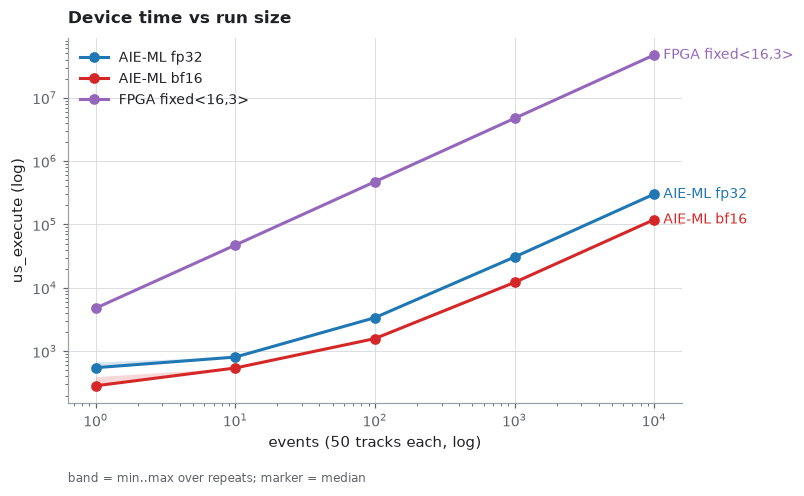


            impl  points  fixed us  marginal ns/track  worst resid %
     AIE-ML fp32       5     492.6              601.9            5.0
     AIE-ML bf16       5     345.2              237.9           25.3
FPGA fixed<16,3>       5      75.2            94660.3            0.5

  "fixed us" is paid once per invocation and is host/driver side --
  no change to the array or the fabric reduces it. "marginal" is what
  the design actually costs per track, and is what a big run
  converges to.


In [4]:
if not RUNS:
    print('(no data)')
else:
    fit_rows = []
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    for r in impl_runs('hw') or impl_runs('hw_emu'):
        impl = r['impl']
        p = primary(r['df'])
        if p.empty:
            continue
        g = agg(p, 'us_execute')
        ev = g.index.to_numpy(float)
        tr = ev * TRACKS_PER_EVENT
        med = g['median'].to_numpy(float)

        ax.plot(ev, med, marker='o', color=COL[impl], label=LABEL[impl], zorder=3)
        # min/max band rather than error bars: with 5 repeats the full range is
        # more honest than a standard deviation of five samples.
        ax.fill_between(ev, g['min'], g['max'], color=COL[impl], alpha=0.18, lw=0)
        # Direct label at the line end, so identity never rests on colour alone.
        ax.annotate(LABEL[impl], (ev[-1], med[-1]), textcoords='offset points',
                    xytext=(6, 0), color=COL[impl], fontsize=9, va='center')

        if len(ev) >= 2:
            A = np.column_stack([np.ones_like(tr), tr])
            (fixed, marginal), *_ = np.linalg.lstsq(A, med, rcond=None)
            pred = A @ (fixed, marginal)
            fit_rows.append({
                'impl': LABEL[impl], 'points': len(ev),
                'fixed us': round(fixed, 1),
                'marginal ns/track': round(marginal * 1e3, 1),
                'worst resid %': round(100 * np.max(np.abs(pred - med) / med), 1),
            })

    ax.set_xscale('log'); ax.set_yscale('log')
    style(ax, 'Device time vs run size',
          'events (50 tracks each, log)', 'us_execute (log)',
          'band = min..max over repeats; marker = median')
    ax.legend(loc='upper left')
    save(fig, 'scan_scaling.png'); plt.show()

    if fit_rows:
        print()
        print(pd.DataFrame(fit_rows).to_string(index=False))
        print()
        print('  "fixed us" is paid once per invocation and is host/driver side --')
        print('  no change to the array or the fabric reduces it. "marginal" is what')
        print('  the design actually costs per track, and is what a big run')
        print('  converges to.')

  wrote analysis/out/scan_ns_per_track.png


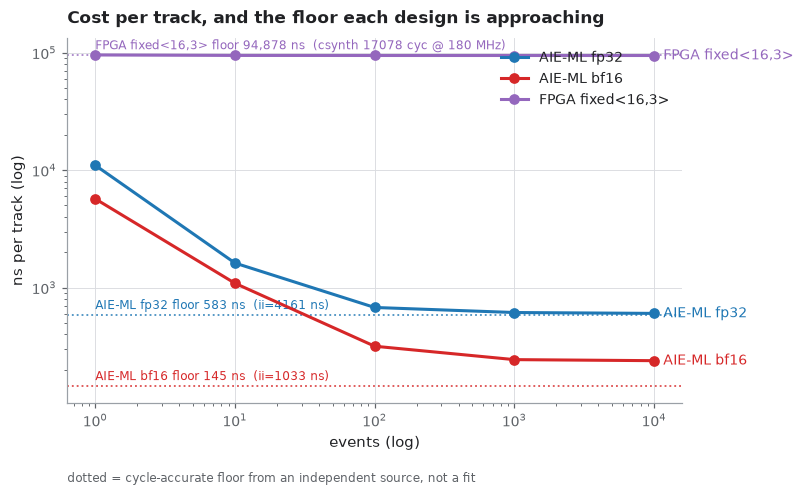


  AIE-ML fp32              11,001 ns/track at      1 event(s)  ->         603 at  10000   (18.2x better)
  AIE-ML bf16               5,699 ns/track at      1 event(s)  ->         239 at  10000   (23.9x better)
  FPGA fixed<16,3>         95,662 ns/track at      1 event(s)  ->      94,660 at  10000   (1.0x better)


In [5]:
if not RUNS:
    print('(no data)')
else:
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    drew = False
    for r in impl_runs('hw') or impl_runs('hw_emu'):
        impl, m = r['impl'], r['meta']
        p = primary(r['df'])
        if p.empty:
            continue
        g = agg(p, 'us_execute')
        ev = g.index.to_numpy(float)
        ns = g['median'].to_numpy(float) * 1e3 / (ev * TRACKS_PER_EVENT)
        ax.plot(ev, ns, marker='o', color=COL[impl], label=LABEL[impl], zorder=3)
        ax.annotate(LABEL[impl], (ev[-1], ns[-1]), textcoords='offset points',
                    xytext=(6, 0), color=COL[impl], fontsize=9, va='center')
        drew = True

        # The asymptote each one is walking toward, from an INDEPENDENT source.
        #
        # AIE: ii_ns is the measured initiation interval per 8-track iteration,
        # and an event occupies 7 iterations for 50 real tracks -- the 6 padding
        # slots cost time but are not tracks. So ns/real track = ii * 7 / 50.
        # PL: csynth's TrackLoop latency at the linked clock.
        # II_NS (cell 2), NOT scan_meta's ii_ns: board scans taken before 2026-09-14
        # carry the old port-averaged value (bf16 1033 ns against a 1650 ns tail).
        if impl in II_NS:
            asym = II_NS[impl] * ITER_PER_EVENT / TRACKS_PER_EVENT
            src = f"ii={II_NS[impl]:.0f} ns"
        elif impl == 'pl_fixed':
            asym = PL_CSYNTH_US_PER_TRACK * 1e3
            src = f'csynth {PL_CSYNTH_CYCLES} cyc @ {PL_CLOCK_MHZ:.0f} MHz'
        else:
            continue
        ax.axhline(asym, color=COL[impl], ls=':', lw=1.2, alpha=0.8)
        ax.annotate(f'{LABEL[impl]} floor {asym:,.0f} ns  ({src})',
                    (ev[0], asym), textcoords='offset points', xytext=(0, 4),
                    color=COL[impl], fontsize=8)

    if drew:
        ax.set_xscale('log'); ax.set_yscale('log')
        style(ax, 'Cost per track, and the floor each design is approaching',
              'events (log)', 'ns per track (log)',
              'dotted = cycle-accurate floor from an independent source, not a fit')
        ax.legend(loc='upper right')
        save(fig, 'scan_ns_per_track.png'); plt.show()

        print()
        for r in impl_runs('hw') or impl_runs('hw_emu'):
            p = primary(r['df'])
            if p.empty:
                continue
            g = agg(p, 'us_execute')
            ev = g.index.to_numpy(float)
            ns = g['median'].to_numpy(float) * 1e3 / (ev * TRACKS_PER_EVENT)
            print(f"  {LABEL[r['impl']]:<20s} {ns[0]:>10,.0f} ns/track at "
                  f"{int(ev[0]):>6d} event(s)  ->  {ns[-1]:>10,.0f} at "
                  f"{int(ev[-1]):>6d}   ({ns[0]/ns[-1]:.1f}x better)")

## 3. Where the time goes

**Read the AIE columns with care.** Input DMA, compute and output DMA overlap by
design there — the graph consumes `x` as it arrives, and waiting on the input
transfer before `graph.run()` deadlocks because nothing drains the shim DMA until
the graph is running. So for the AIE, `us_h2d` is the cost of *issuing* the two
async transfers and `us_d2h` is the un-overlapped *tail* after `graph.wait()`.
Only the PL design, which is memory-mapped and synchronous, has genuine per-phase
transfer numbers.

`us_stage` is host-side in both: slot padding and the bf16 conversion for the AIE,
the strided repack for the PL. It is not device time and no hardware change
touches it.

  wrote analysis/out/scan_phases_aie_fp32.png


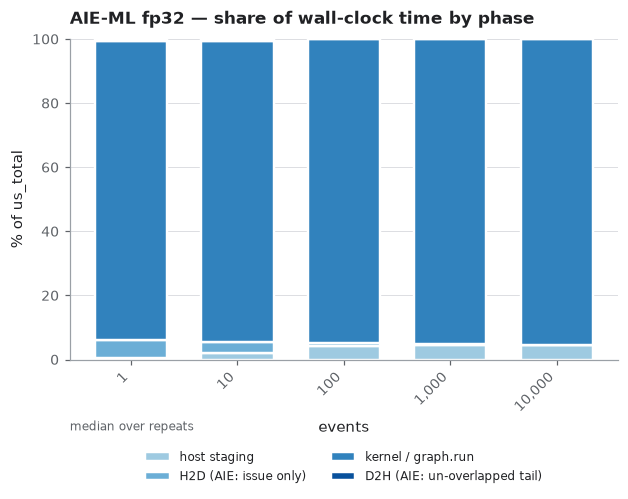

  wrote analysis/out/scan_phases_aie_bf16.png


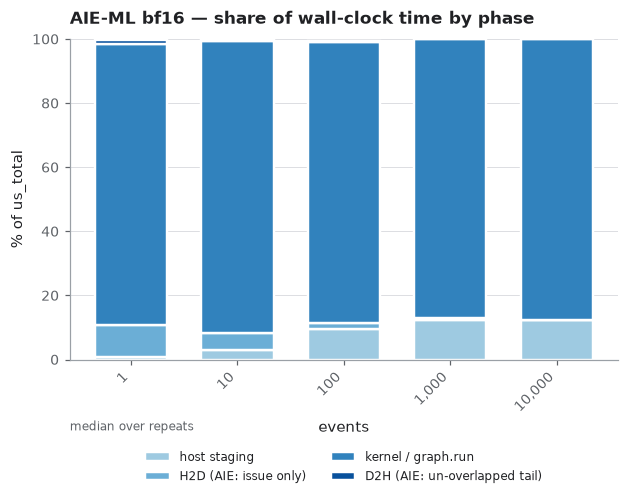

  wrote analysis/out/scan_phases_pl_fixed.png


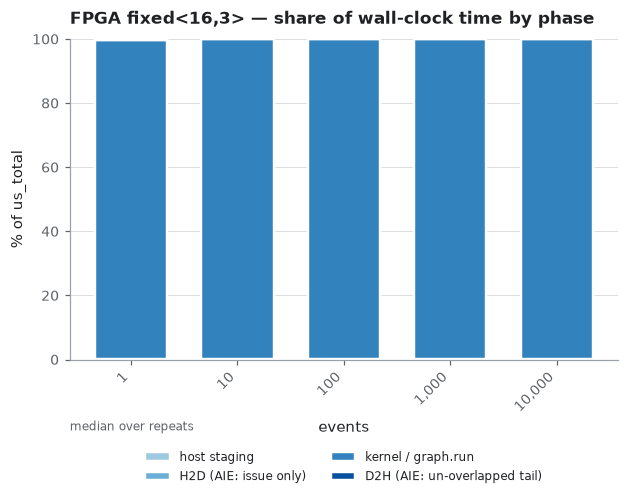


Absolute medians, us:

  AIE-ML fp32 / hw
        us_stage  us_h2d  us_kernel  us_d2h  us_execute  us_total
events                                                           
1            2.7    30.4      516.6     3.1       550.1     553.3
10          15.7    30.6      775.0     3.7       808.9     825.4
100        146.3    34.0     3347.5     4.3      3385.8    3532.9
1000      1439.4    81.8    30578.7     7.5     30666.7   32112.7
10000    14194.1    84.7   301329.3     7.4    301425.7  315605.9

  AIE-ML bf16 / hw
        us_stage  us_h2d  us_kernel  us_d2h  us_execute  us_total
events                                                           
1            2.5    28.9      252.8     3.3       284.9     288.2
10          17.3    28.4      513.3     3.3       544.1     562.0
100        168.7    32.5     1547.4     3.6      1583.5    1764.0
1000      1711.3    78.8    12093.8     7.4     12176.9   13889.1
10000    16694.0    82.1   119195.1     7.6    119289.9  135984.7

  FPGA fixed

In [6]:
if not RUNS:
    print('(no data)')
else:
    present = impl_runs('hw') or impl_runs('hw_emu')
    # One implementation per figure. The stacks were never compared segment to
    # segment across implementations -- each is read on its own -- so sharing a
    # canvas only cost each one half the width.
    for r in present:
        impl = r['impl']
        p = primary(r['df'])
        if p.empty:
            continue
        fig, axi = plt.subplots(figsize=(5.6, 4.4))
        ev = sorted(p['events'].unique())
        x = np.arange(len(ev), dtype=float)
        bottom = np.zeros(len(ev))
        for ph in PHASES:
            med = np.array([p[p['events'] == e][ph].median() for e in ev], float)
            tot = np.array([p[p['events'] == e]['us_total'].median() for e in ev], float)
            frac = 100.0 * med / np.where(tot > 0, tot, np.nan)
            # 1.6px white edge = the 2px surface gap between stacked segments, so
            # adjacent fills never touch and read as one block.
            axi.bar(x, frac, bottom=bottom, width=0.68, color=PHASE_COL[ph],
                    edgecolor='white', linewidth=1.6, label=PHASE_LABEL[ph])
            bottom += np.nan_to_num(frac)
        axi.set_xticks(x)
        axi.set_xticklabels([f'{int(e):,}' for e in ev], rotation=45, ha='right')
        axi.set_ylim(0, 100)
        axi.grid(axis='x', visible=False)
        axi.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.42), fontsize=8)
        style(axi, f'{LABEL[impl]} — share of wall-clock time by phase',
              'events', '% of us_total', 'median over repeats')
        save(fig, f'scan_phases_{impl}.png'); plt.show()

    print()
    print('Absolute medians, us:')
    for r in present:
        p = primary(r['df'])
        if p.empty:
            continue
        t = p.groupby('events')[PHASES + ['us_execute', 'us_total']].median().round(1)
        print()
        print(f"  {LABEL[r['impl']]} / {r['target']}")
        print(t.to_string())


## 4. What the overhead actually is

Two different quantities, so two panels rather than one chart pretending they are
comparable:

- **AIE** — `us_modelled = II x iterations` is the array's own time, from the
  measured initiation interval. It is recomputed here from `II_NS` in §0 rather than
  read from the CSV, whose `ii_ns` is stale for bf16 in scans before 2026-09-14. `us_execute - us_modelled` is everything else:
  the per-`graph.run()` round trip and the GMIO arming. This is a subtraction
  against a number the design itself supplies.
- **PL** — there is no equivalent runtime figure, so the comparison is against
  csynth: TrackLoop cycles per track at the `KERNEL_FREQ` clock, both read from the
  build in §0 (17,078 cycles at 180 MHz = 4.74 ms per 50-track event, worst case).
  RTL co-simulation measures 4.733 ms; see `analysis/rtda_timing.ipynb` §5.

  wrote analysis/out/scan_overhead_aie.png


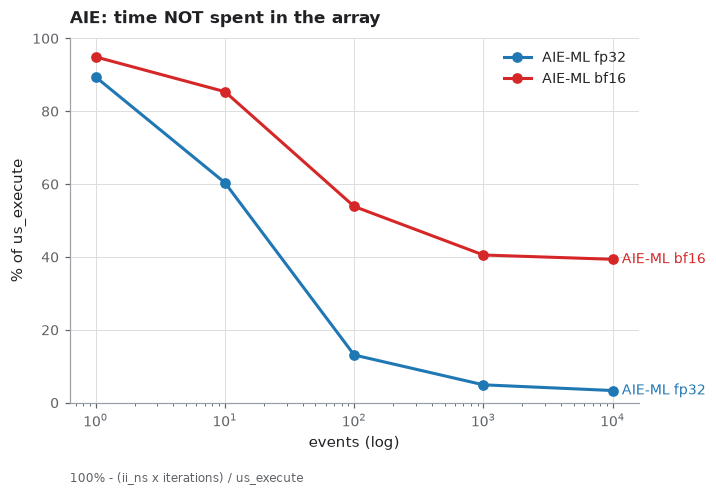

  wrote analysis/out/scan_overhead_pl.png


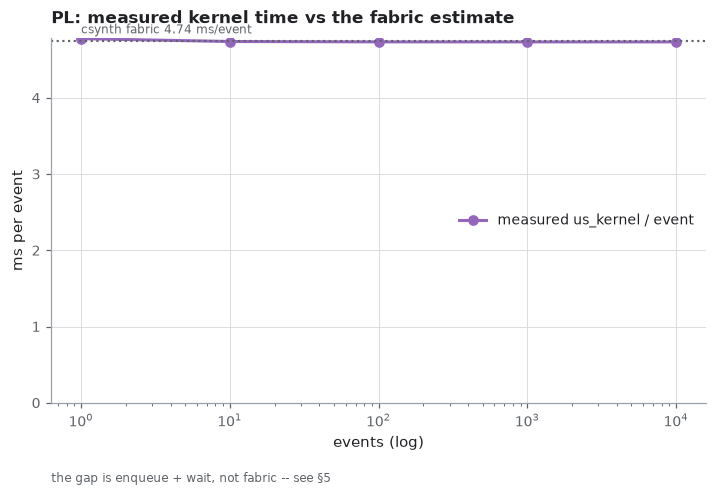

In [7]:
if not RUNS:
    print('(no data)')
else:
    aie = [r for r in (impl_runs('hw') or impl_runs('hw_emu')) if r['impl'].startswith('aie')]
    pl  = [r for r in (impl_runs('hw') or impl_runs('hw_emu')) if r['impl'] == 'pl_fixed']
    if not aie and not pl:
        print('(nothing to attribute)')
    # Two unrelated quantities on two different y axes -- % of us_execute, and
    # ms per event. They were only ever side by side because they belong to the
    # same section, so each now gets its own PNG.
    if aie:
        fig, axi = plt.subplots(figsize=(6.4, 4.4))
        for r in aie:
            p = primary(r['df'])
            if p.empty or 'us_modelled' not in p:
                continue
            g = p.groupby('events')[['us_execute', 'us_modelled']].median()
            # Recomputed, not read: see II_NS in §0. The host runs events + 1
            # (its flush event), 7 iterations each.
            g['us_modelled'] = II_NS[r['impl']] * 1e-3 * ITER_PER_EVENT * (g.index.to_numpy(float) + 1)
            ev = g.index.to_numpy(float)
            pct = 100.0 * (g['us_execute'] - g['us_modelled']) / g['us_execute']
            axi.plot(ev, pct, marker='o', color=COL[r['impl']], label=LABEL[r['impl']])
            axi.annotate(LABEL[r['impl']], (ev[-1], pct.to_numpy()[-1]),
                         textcoords='offset points', xytext=(6, 0),
                         color=COL[r['impl']], fontsize=9, va='center')
        axi.set_xscale('log'); axi.set_ylim(0, 100)
        style(axi, 'AIE: time NOT spent in the array',
              'events (log)', '% of us_execute',
              '100% - (ii_ns x iterations) / us_execute')
        axi.legend(loc='upper right')
        save(fig, 'scan_overhead_aie.png'); plt.show()
    if pl:
        fig, axi = plt.subplots(figsize=(6.4, 4.4))
        ev = None
        for r in pl:
            p = primary(r['df'])
            if p.empty:
                continue
            g = agg(p, 'us_kernel')
            ev = g.index.to_numpy(float)
            per_ev = g['median'].to_numpy(float) / ev / 1e3      # ms per event
            axi.plot(ev, per_ev, marker='o', color=COL['pl_fixed'],
                     label='measured us_kernel / event')
            axi.fill_between(ev, g['min'] / ev / 1e3, g['max'] / ev / 1e3,
                             color=COL['pl_fixed'], alpha=0.18, lw=0)
        csynth_ms = PL_CSYNTH_US_PER_TRACK * TRACKS_PER_EVENT / 1e3
        axi.axhline(csynth_ms, color='#5f6368', ls=':', lw=1.4)
        if ev is not None:
            axi.annotate(f'csynth fabric {csynth_ms:.2f} ms/event',
                         (ev[0], csynth_ms), textcoords='offset points',
                         xytext=(0, 5), fontsize=8, color='#5f6368')
        axi.set_xscale('log'); axi.set_ylim(bottom=0)
        style(axi, 'PL: measured kernel time vs the fabric estimate',
              'events (log)', 'ms per event',
              'the gap is enqueue + wait, not fabric -- see §5')
        axi.legend(loc='center right')
        save(fig, 'scan_overhead_pl.png'); plt.show()


## 5. Throughput

`2 x 264,192 MAC/track` at the measured rate, against each design's own ceiling.
The AIE ceiling is its atom: `2 x 264,192 x 8 tracks / ii_ns`.

  wrote analysis/out/scan_throughput.png


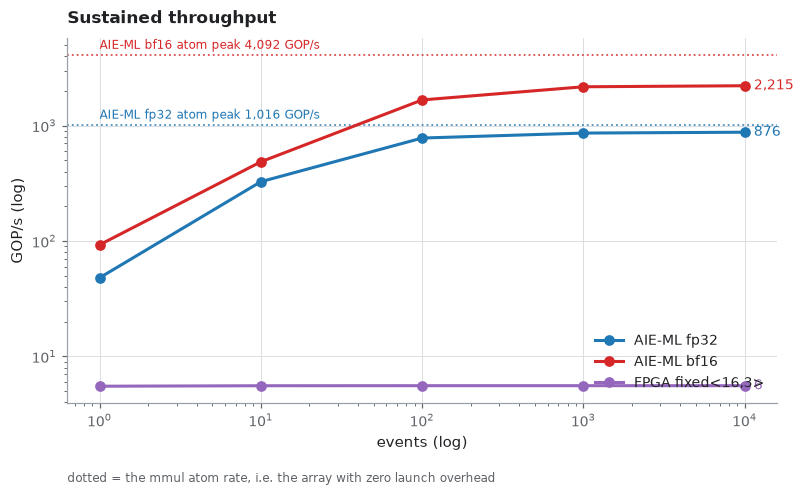

In [8]:
if not RUNS:
    print('(no data)')
else:
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    drew = False
    for r in impl_runs('hw') or impl_runs('hw_emu'):
        impl, m = r['impl'], r['meta']
        p = primary(r['df'])
        if p.empty:
            continue
        g = agg(p, 'us_execute')
        ev = g.index.to_numpy(float)
        gops = (OPS_PER_MAC * MACS_PER_TRACK * ev * TRACKS_PER_EVENT
                / (g['median'].to_numpy(float) * 1e-6) / 1e9)
        ax.plot(ev, gops, marker='o', color=COL[impl], label=LABEL[impl], zorder=3)
        ax.annotate(f'{gops[-1]:,.0f}', (ev[-1], gops[-1]), textcoords='offset points',
                    xytext=(6, 0), color=COL[impl], fontsize=9, va='center')
        drew = True
        if impl in II_NS:                       # not scan_meta's stale ii_ns -- see cell 8
            peak = OPS_PER_MAC * MACS_PER_TRACK * BATCH / (II_NS[impl] * 1e-9) / 1e9
            ax.axhline(peak, color=COL[impl], ls=':', lw=1.2, alpha=0.8)
            ax.annotate(f'{LABEL[impl]} atom peak {peak:,.0f} GOP/s',
                        (ev[0], peak), textcoords='offset points', xytext=(0, 4),
                        color=COL[impl], fontsize=8)
    if drew:
        ax.set_xscale('log'); ax.set_yscale('log')
        style(ax, 'Sustained throughput', 'events (log)', 'GOP/s (log)',
              'dotted = the mmul atom rate, i.e. the array with zero launch overhead')
        ax.legend(loc='lower right')
        save(fig, 'scan_throughput.png'); plt.show()

## 6. The PL bottleneck — per-call overhead, or slow fabric?

`n_tracks` is a runtime `s_axilite` argument and `TrackLoop` is
`for (j = 0; j < n_tracks; j++)`, so one kernel call can process 50, 100, 500 or
1000 tracks. Fitting `us_call = fixed + marginal x tracks` over that sweep
separates the two candidate explanations, and they predict very different numbers:

| if marginal is | then | and |
|---|---|---|
| ≈ 42 us/track | csynth is right; the gap is **per-call driver cost** | batching events into one call fixes it |
| ≈ 114 us/track | the **fabric is slower** than csynth predicted, or the achieved clock is below 150 MHz | batching will not help |

The 128-wide mean is meaningless for `n_tracks != 50` — the accumulator divides by
the event size — which is why these rows carry `mode=tpc` and are never plotted as
event throughput.

  wrote analysis/out/scan_pl_calls_hw_tracks_per_call.png


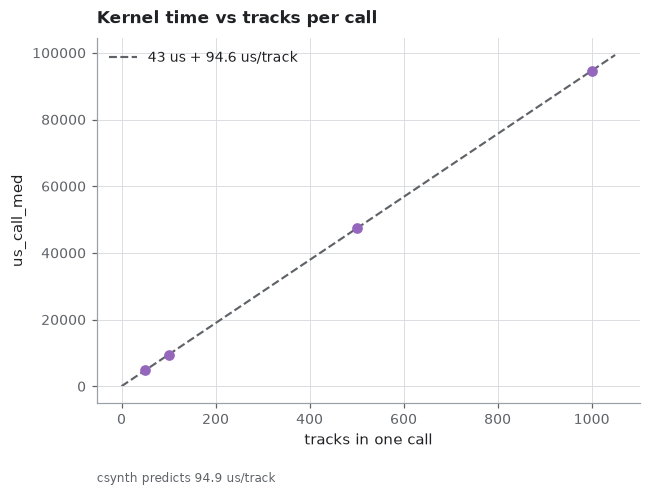

  wrote analysis/out/scan_pl_calls_hw_per_call.png


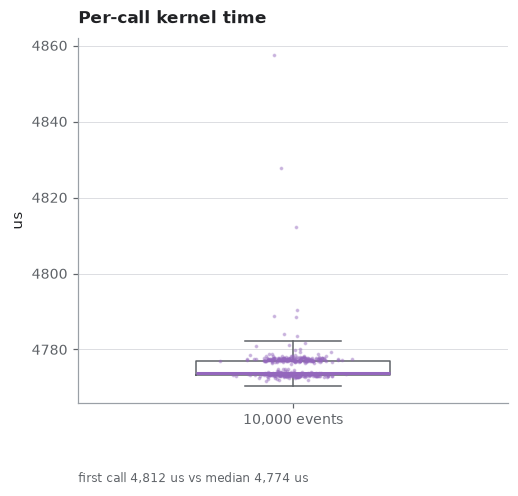

  wrote analysis/out/scan_pl_calls_hw_call_structure.png


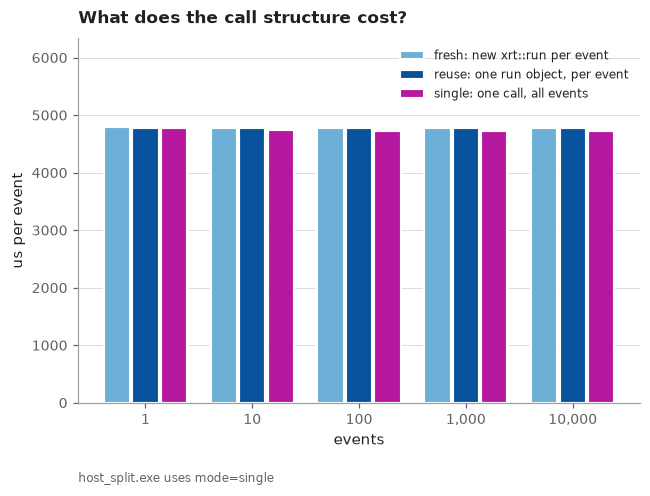


  at 10,000 events: 4,780.1 us/event with one call per event  ->  4,733.0 us/event with a single call (+0.98%)

 tracks_per_call  launches  us_call_min  us_call_med  us_call_max
              50        20     4771.154    4772.6140     4798.574
             100        20     9499.378    9501.7185     9508.898
             500        20    47336.822   47338.5670    47347.881
            1000        20    94631.333   94633.2290    94642.193

  fit: us_call = 43.0 us + 94.59 us/track
  csynth       = 94.88 us/track (17078 cycles @ 180 MHz)
  -> the bottleneck is the fabric itself -- one call for all 10,000 events is worth 0.98%


In [9]:
pl = [r for r in RUNS if r['impl'] == 'pl_fixed']
if not pl:
    print('(no PL scan)')
else:
    for r in pl:
        d = r['df']
        tpc = d[d['mode'] == 'tpc'].sort_values('tracks_per_call')
        fresh = d[d['mode'] == 'fresh']
        reuse = d[d['mode'] == 'reuse']
        single = d[d['mode'] == 'single']

        if tpc.empty and not r['calls'] and reuse.empty and single.empty:
            print(f"  {r['target']}: no PL diagnostics in this run")
            continue
        tag = r['target']

        # ---- the fit -------------------------------------------------------
        if not tpc.empty:
            fig, axi = plt.subplots(figsize=(5.8, 4.4))
            n = tpc['tracks_per_call'].to_numpy(float)
            y = tpc['us_call_med'].to_numpy(float)
            axi.plot(n, y, marker='o', color=COL['pl_fixed'], ls='none', zorder=3)
            axi.fill_between(n, tpc['us_call_min'], tpc['us_call_max'],
                             color=COL['pl_fixed'], alpha=0.18, lw=0)
            if len(n) >= 2:
                A = np.column_stack([np.ones_like(n), n])
                (fixed, marginal), *_ = np.linalg.lstsq(A, y, rcond=None)
                xs = np.linspace(0, n.max() * 1.05, 50)
                axi.plot(xs, fixed + marginal * xs, color='#5f6368', lw=1.4, ls='--',
                         label=f'{fixed:,.0f} us + {marginal:.1f} us/track')
                axi.axhline(0, color='#dadce0', lw=0.6)
                axi.legend(loc='upper left')
                # MEASURED, not inferred. mode=single runs the whole event
                # count in ONE kernel call, so the difference against mode=fresh
                # IS the per-call overhead -- there is no need to guess it from
                # where the fit's intercept sits relative to csynth.
                #
                # The old heuristic compared `marginal` against a midpoint of
                # csynth and the 50-track point. It was calibrated when
                # PL_CSYNTH_US_PER_TRACK was a stale 42.23; with the correct
                # 94.88 the two terms sit either side of the marginal cost and
                # it flipped to "batching would fix it" -- against data showing
                # batching is worth 1%.
                verdict = None
                if not single.empty and not fresh.empty:
                    _both = set(single['events']) & set(fresh['events'])
                    if _both:
                        _e = max(_both)
                        _f = fresh[fresh['events'] == _e]['us_execute'].median() / _e
                        _s = single[single['events'] == _e]['us_execute'].median() / _e
                        verdict = (f'the fabric itself -- one call for all {int(_e):,} '
                                   f'events is worth {100*(_f-_s)/_f:.2f}%')
                if verdict is None:
                    verdict = ('unknown -- no mode=single rows to compare against. '
                               'Re-run the scan with RTDA_SCAN_MODES=fresh,reuse,single')
            else:
                fixed = marginal = float('nan'); verdict = 'need >= 2 tpc points'
            style(axi, 'Kernel time vs tracks per call', 'tracks in one call',
                  'us_call_med',
                  f'csynth predicts {PL_CSYNTH_US_PER_TRACK:.1f} us/track')
            save(fig, f'scan_pl_calls_{tag}_tracks_per_call.png'); plt.show()

        # ---- the distribution ---------------------------------------------
        if r['calls']:
            fig, axi = plt.subplots(figsize=(4.6, 4.4))
            ev = max(r['calls'])
            s = r['calls'][ev]['us_kernel'].to_numpy(float)
            axi.boxplot([s], widths=0.45, vert=True, showfliers=False,
                        medianprops=dict(color=COL['pl_fixed'], lw=2),
                        boxprops=dict(color='#5f6368'),
                        whiskerprops=dict(color='#5f6368'),
                        capprops=dict(color='#5f6368'))
            axi.plot(np.full(min(len(s), 400), 1.0) +
                     np.random.default_rng(0).normal(0, 0.045, min(len(s), 400)),
                     s[:400], '.', ms=3, color=COL['pl_fixed'], alpha=0.35)
            axi.set_xticks([1]); axi.set_xticklabels([f'{ev:,} events'])
            axi.grid(axis='x', visible=False)
            style(axi, 'Per-call kernel time', None, 'us',
                  f'first call {s[0]:,.0f} us vs median {np.median(s):,.0f} us')
            save(fig, f'scan_pl_calls_{tag}_per_call.png'); plt.show()

        # ---- what the call structure costs ----------------------------------
        # us_execute PER EVENT, not us_call_med. mode=single is ONE call
        # covering every event, so its per-call time IS the whole run -- putting
        # that beside a per-event call time would compare 5.7 ms against 5.7 s.
        # Per event is the only quantity all three shapes share.
        shapes = [(fresh,  'fresh: new xrt::run per event',    '#6baed6'),
                  (reuse,  'reuse: one run object, per event', '#08519c'),
                  (single, 'single: one call, all events',     '#b5179e')]
        shapes = [t for t in shapes if not t[0].empty]
        if len(shapes) >= 2:
            fig, axi = plt.subplots(figsize=(5.8, 4.4))
            ev = sorted(set.intersection(*[set(t[0]['events']) for t in shapes]))
            x = np.arange(len(ev), dtype=float)
            w = 0.8 / len(shapes)
            for off, (sub, name, c) in enumerate(shapes):
                v = [sub[sub['events'] == e]['us_execute'].median() / e for e in ev]
                axi.bar(x + (off - (len(shapes) - 1) / 2) * w, v, width=w * 0.92,
                        color=c, edgecolor='white', linewidth=1.4, label=name)
            axi.set_xticks(x); axi.set_xticklabels([f'{int(e):,}' for e in ev])
            axi.grid(axis='x', visible=False)
            # The bars start at zero and nearly fill the axes, so the legend has
            # nowhere to sit inside them without covering data. Make room.
            _top = max(sub[sub['events'] == e]['us_execute'].median() / e
                       for sub, _, _ in shapes for e in ev)
            axi.set_ylim(0, _top * 1.32)
            axi.legend(loc='upper right', fontsize=8, framealpha=0.95)
            style(axi, 'What does the call structure cost?', 'events',
                  'us per event',
                  f'host_split.exe uses mode={pl_shape(d)}')
            save(fig, f'scan_pl_calls_{tag}_call_structure.png'); plt.show()

            # The direct answer, when both shapes were measured. Until mode=single
            # existed this could only be inferred from the tpc fit below.
            if not single.empty and not fresh.empty:
                both = set(single['events']) & set(fresh['events'])
                if both:
                    e = max(both)
                    a = fresh[fresh['events'] == e]['us_execute'].median() / e
                    b = single[single['events'] == e]['us_execute'].median() / e
                    print()
                    print(f'  at {int(e):,} events: {a:,.1f} us/event with one call per '
                          f'event  ->  {b:,.1f} us/event with a single call '
                          f'({100 * (a - b) / a:+.2f}%)')

        if not tpc.empty and len(tpc) >= 2:
            print()
            print(tpc[['tracks_per_call', 'launches', 'us_call_min', 'us_call_med',
                       'us_call_max']].to_string(index=False))
            print()
            print(f'  fit: us_call = {fixed:,.1f} us + {marginal:.2f} us/track')
            print(f'  csynth       = {PL_CSYNTH_US_PER_TRACK:.2f} us/track '
                  f'({PL_CSYNTH_CYCLES} cycles @ {PL_CLOCK_MHZ:.0f} MHz)')
            print(f'  -> the bottleneck is {verdict}')


## 7. The AIE launch cost, measured directly

The same event count split across N `graph.run()` calls, each with its own flush
event and its own offset into the same pair of BOs. If the fixed cost is really
per-launch, splitting 1000 events into 10 launches should add 9 x that cost and
nothing else — which turns an inferred intercept into a measurement.

  wrote analysis/out/scan_launches.png


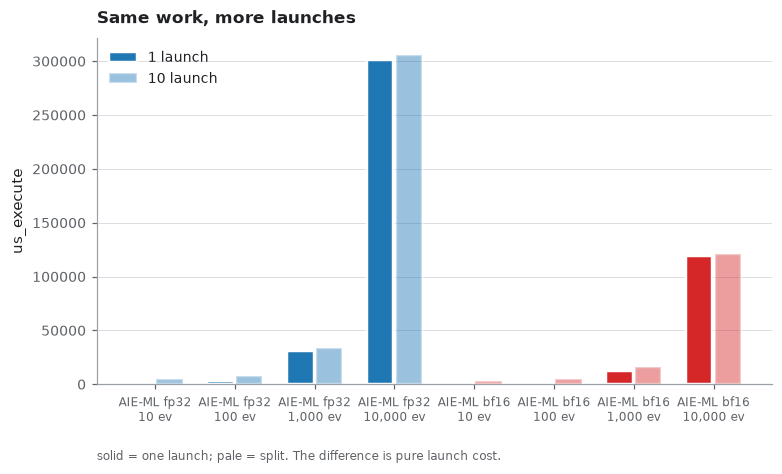


       impl  events  us, 1 launch  us, 10 launches  implied us per extra launch
AIE-ML fp32      10         808.9           5363.3                        506.0
AIE-ML fp32     100        3385.8           7926.3                        504.5
AIE-ML fp32    1000       30666.7          33741.4                        341.6
AIE-ML fp32   10000      301425.7         305923.6                        499.8
AIE-ML bf16      10         544.1           2711.3                        240.8
AIE-ML bf16     100        1583.5           5331.6                        416.5
AIE-ML bf16    1000       12176.9          15721.9                        393.9
AIE-ML bf16   10000      119289.9         121243.7                        217.1

  Compare "implied us per extra launch" with the fixed term of the
  §2 fit. Two independent routes to the same number agreeing is
  what makes it a measurement rather than an artefact of one method.


In [10]:
aie = [r for r in RUNS if r['impl'].startswith('aie')]
if not aie:
    print('(no AIE scan)')
else:
    rows, drew = [], False
    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    width = 0.36
    labels = []
    for i, r in enumerate(aie):
        d = primary(r['df']) if False else r['df'][r['df']['mode'] == 'gmio']
        splits = sorted(d['launches'].unique())
        if len(splits) < 2:
            continue
        ev_common = sorted(set.intersection(*[set(d[d['launches'] == s]['events'])
                                              for s in splits]))
        for e in ev_common:
            sub = d[d['events'] == e]
            base = sub[sub['launches'] == splits[0]]['us_execute'].median()
            for j, s in enumerate(splits):
                v = sub[sub['launches'] == s]['us_execute'].median()
                pos = len(labels) + (j - (len(splits) - 1) / 2) * width
                ax.bar(pos, v, width=width * 0.92,
                       color=COL[r['impl']], alpha=1.0 if s == splits[0] else 0.45,
                       edgecolor='white', linewidth=1.6,
                       label=(f'{s} launch' if len(labels) == 0 else None))
                if s != splits[0]:
                    per = (v - base) / (s - splits[0])
                    rows.append({'impl': LABEL[r['impl']], 'events': int(e),
                                 f'us, {splits[0]} launch': round(base, 1),
                                 f'us, {s} launches': round(v, 1),
                                 'implied us per extra launch': round(per, 1)})
            labels.append(f"{LABEL[r['impl']]}\n{int(e):,} ev")
            drew = True
    if drew:
        ax.set_xticks(np.arange(len(labels))); ax.set_xticklabels(labels, fontsize=8)
        ax.grid(axis='x', visible=False)
        ax.legend(loc='upper left')
        style(ax, 'Same work, more launches', None, 'us_execute',
              'solid = one launch; pale = split. The difference is pure launch cost.')
        save(fig, 'scan_launches.png'); plt.show()
        print()
        print(pd.DataFrame(rows).to_string(index=False))
        print()
        print('  Compare "implied us per extra launch" with the fixed term of the')
        print('  §2 fit. Two independent routes to the same number agreeing is')
        print('  what makes it a measurement rather than an artefact of one method.')
    else:
        print('(only one launch count in this scan -- set RTDA_SCAN_SPLITS=1,10)')

## 8. Without an accelerator — a host CPU and a GPU

Everything above compares three accelerator implementations against each other.
None of them was compared against the obvious alternative: just run the network
on the host.

`cpu/scan_cpu.py` runs the same sweep — same event counts, same 5 repeats, same
`scan.csv` schema — through `model/rtda_ref.forward(roll='streaming')`, which
*is* the reference rather than a copy of it. `forward()` is already fully
vectorised (14 `np.matmul` calls regardless of track count), so this is a
BLAS-bound baseline, not an interpreter benchmark.

**This is not a like-for-like comparison, and it must not be read as one.** The
accelerator numbers include XRT buffer syncs and kernel launches driven by the
VEK280's quad-A72 PS. The CPU number has no device transfer at all — host and
compute are the same silicon — and it runs on a 32-core EPYC 9354P at up to
3.8 GHz. One is a card in a system; the other is the system. The asymmetry is
the interesting part, not a flaw, but it belongs on the figure.

Two properties are asserted by `make -C cpu check`, not assumed:

- every thread count uses the **same 50-event chunk**, because unchunked the
  8-thread run measured *superlinear* 9.6× — cache, not parallelism, with the
  1-thread run streaming 20 MB activation arrays out of DRAM;
- chunk boundaries are **bit-identical** to an un-split run. The receptive
  field is exactly 4 tracks deep, so starting a chunk 3 tracks early and
  discarding them reproduces it exactly (`np.array_equal`, not a tolerance).

fp32, not the reference's fp64: fp64 GEMM runs at half the SIMD width (measured
2.24× slower), and the comparison is against fp32 and bf16 hardware. The
measured cost of fp32 is 6.9e-07 relative on the event means, against bf16's
2.9e-04.

### The GPU

`gpu/scan_gpu.py` runs the same sweep on an NVIDIA card via `gpu/rtda_torch.py`
— a torch transcription of `rtda_ref`, checked against it at float64 on every
run (measured 1.4e-15, i.e. floating-point noise). It is the one place in this
repo where the forward pass had to be written a second time, because torch
cannot execute numpy on a GPU; the check is what stops it drifting.

Unlike the CPU, **a GPU is a card on PCIe, so `us_h2d` and `us_d2h` are real** —
this is the first non-PL row in the whole notebook whose per-phase breakdown is
a genuine three-phase transfer rather than a placeholder.

Three call shapes are measured, and only the first is plotted beside the other
implementations, for the same reason `primary()` excludes `reuse` and `tpc`:

- `single` — one transfer, one forward, one transfer back, for the whole run.
  **The comparable row.**
- `fresh` — one per event, the shape `pl_fixed` used to have.
- `graph` — identical maths with the ~50 kernel launches captured and replayed
  as one. A **diagnostic**, and it corrected a guess: the cost at small batch
  was *predicted* to be the host driving the card, and it is not. CUDA events
  put the GPU at **95% busy even at one event** — host overhead is ~20 µs out of
  ~558. The floor is *device-side* per-kernel launch latency across ~50 tiny
  kernels, which `graph` removes by replaying them as one (533 → 139 µs). Same
  fix, different cause, and only the measurement distinguishes them.

Two results here were not predicted and are worth reading off the figures:

**The GPU stops improving long before 10,000 events.** Every other
implementation here is monotone; this one turns back up, and by 10,000 events is
2.3× (fp32) to 3.0× (bf16) worse than its own best.

The cause is cache, and it was **tested rather than asserted**. If the upturn is
a cache effect it has to happen at a fixed number of *bytes*, so fp32 and tf32 —
which share float32 storage — must turn at the same run size, and bf16, whose
tensors are half the size, must turn at twice it. A denser sweep says:

| variant | best at | µs/event | one `(n,128)` activation |
|---|---|---|---|
| bf16 | 1,000 events | 0.99 | 12.8 MB |
| fp32 | 500 events | 2.54 | 12.8 MB |
| tf32 | 500 events | 1.84 | 12.8 MB |

All three peak at the **same 12.8 MB activation**, and bf16's turn point is
exactly **2.0×** fp32's in events. That is a cache effect and not a run-size
effect. The L40S has 96 MB of L2 and each of the 14 layers reads and writes one
of these tensors, so several are live at once; past that point they all stream
from GDDR6.

Because of that, the comparison table below uses each implementation's **best**
per-event cost across the sweep rather than its value at the largest run. For
everything except the GPU those are the same number.


cpu: AMD EPYC 9354P 32-Core Processor
     64 logical cores, numpy 2.3.4, blas scipy-openblas 0.3.30 pinned to 1 thread
     dtype=fp32 chunk=50 events  threads=1,2,4,8,16,32
gpu: NVIDIA L40S  (index 3)
     driver 595.58.03, cuda 12.8, torch 2.8.0+cu128
     210/2520 MHz, 350.0 W limit, variants fp32,bf16,tf32, modes single,fresh,graph


  wrote analysis/out/scan_vs_accel.png


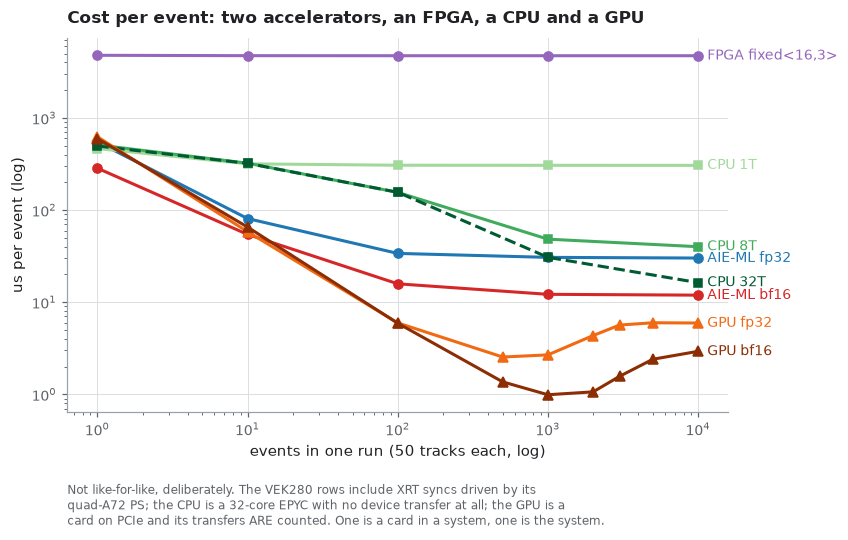


  Left-hand side is fixed cost, and the CPU has its own version of it:
  below 100 events there are fewer chunks than threads, so thread count stops
  mattering. That is the chunk size showing through, not the CPU.


In [11]:
# ---------------------------------------------------------------------------
# The CPU scan is loaded HERE rather than in load_scan(), deliberately.
#
# Adding 'cpu' to IMPLS would pull a CPU line into all seven figures above --
# which are about three hardware implementations and have been read and checked
# as such. Keeping the loader local bounds the blast radius to this section and
# leaves LABEL/COL/primary() untouched.
#
# The thread count rides in `variant` (fp32_t1 .. fp32_t32) rather than in
# `mode`, so mode='single' keeps meaning what it means for the other flows.
# ---------------------------------------------------------------------------
CPU_DIR  = RESULTS / 'cpu' / 'native'
CPU_META = read_kv(CPU_DIR / 'scan_meta.txt')
CPU      = pd.read_csv(CPU_DIR / 'scan.csv') if (CPU_DIR / 'scan.csv').exists() \
           else pd.DataFrame()

if CPU.empty:
    print('(no CPU scan -- run `make scan_host FLOW=cpu`)')
else:
    CPU['threads'] = CPU['variant'].str.rsplit('_t', n=1).str[-1].astype(int)
    THREADS = sorted(CPU['threads'].unique())
    print(f"cpu: {CPU_META.get('cpu_model','?')}")
    print(f"     {CPU_META.get('cores','?')} logical cores, "
          f"numpy {CPU_META.get('numpy','?')}, blas {CPU_META.get('blas','?')} "
          f"pinned to {CPU_META.get('blas_threads','?')} thread")
    print(f"     dtype={CPU_META.get('dtype','?')} "
          f"chunk={CPU_META.get('chunk_events','?')} events  "
          f"threads={CPU_META.get('threads_list','?')}")


def per_event_us(df):
    """median us_execute per event, indexed by event count."""
    g = agg(df, 'us_execute')
    return g.index.to_numpy(float), (g['median'] / g.index).to_numpy(float)


def hw_per_event(target='hw'):
    """{impl: (events, us/event)} for the hardware runs, from primary() rows."""
    out = {}
    for r in impl_runs(target) or impl_runs('hw_emu'):
        p = primary(r['df'])
        if not p.empty:
            out[r['impl']] = per_event_us(p)
    return out


# ---------------------------------------------------------------------------
# The GPU scan, loaded the same way and for the same reason.
#
# scan_gpu.py can be run with --allow-cpu to smoke-test the harness on a
# machine with no card. Those rows are stamped, and are refused here: a host
# CPU timing plotted as a GPU would be worse than having no GPU line at all.
# ---------------------------------------------------------------------------
GPU_DIR  = RESULTS / 'gpu' / 'native'
GPU_META = read_kv(GPU_DIR / 'scan_meta.txt')
GPU      = pd.read_csv(GPU_DIR / 'scan.csv') if (GPU_DIR / 'scan.csv').exists() \
           else pd.DataFrame()

if not GPU.empty:
    smoke = GPU['notes'].fillna('').str.contains('SMOKE TEST', case=False)
    if smoke.any():
        print(f'  REFUSED: {int(smoke.sum())} of {len(GPU)} GPU rows are stamped')
        print('           "SMOKE TEST ON HOST CPU -- NOT A GPU MEASUREMENT".')
        print('           Re-run gpu/scan_gpu.py on a real card; results/gpu/')
        print('           currently holds a harness test, not a measurement.')
        GPU = GPU[~smoke]

if GPU.empty:
    print('(no GPU scan -- see gpu/README.md; it runs on another machine)')
else:
    print(f"gpu: {GPU_META.get('gpu_model','?')}  (index {GPU_META.get('gpu_index','?')})")
    print(f"     driver {GPU_META.get('driver','?')}, cuda {GPU_META.get('cuda','?')}, "
          f"torch {GPU_META.get('torch','?')}")
    print(f"     {GPU_META.get('sm_clock_mhz','?')}/{GPU_META.get('sm_clock_max_mhz','?')} MHz, "
          f"{GPU_META.get('power_limit_w','?')} W limit, "
          f"variants {GPU_META.get('variants_list','?')}, modes {GPU_META.get('modes','?')}")

# Three shades of one hue: the CPU is ONE implementation at three thread
# counts, not three implementations. The categorical palette above stays
# reserved for "which silicon". The GPU gets its own hue on the same rule.
CPU_SHADE = {1: '#a1d99b', 8: '#41ab5d', 32: '#005a32'}
GPU_SHADE = {'fp32': '#f16913', 'bf16': '#8c2d04', 'tf32': '#fdae6b'}
GPU_PLOT  = ('fp32', 'bf16')          # tf32 is an accuracy diagnostic, not a line


def gpu_primary(variant):
    """mode=single rows for one variant -- the shape comparable to everything else."""
    if GPU.empty:
        return pd.DataFrame()
    return GPU[(GPU['variant'] == variant) & (GPU['mode'] == 'single')]

if not CPU.empty and RUNS:
    HW = hw_per_event()
    fig, ax = plt.subplots(figsize=(7.6, 4.8))

    for impl, (ev, ue) in HW.items():
        ax.plot(ev, ue, marker='o', color=COL[impl], label=LABEL[impl], zorder=3)
        ax.annotate(LABEL[impl], (ev[-1], ue[-1]), textcoords='offset points',
                    xytext=(6, 0), color=COL[impl], fontsize=9, va='center')

    for n in [t for t in (1, 8, 32) if t in THREADS]:
        sub = CPU[CPU['threads'] == n]
        ev, ue = per_event_us(sub)
        # 32 threads is the whole machine and is shown dashed: it answers a
        # different question from the 1 and 8 the sweep was asked for.
        ax.plot(ev, ue, marker='s', ms=5, color=CPU_SHADE[n],
                ls='--' if n == 32 else '-',
                label=f'CPU fp32, {n} thread' + ('s' if n > 1 else ''), zorder=3)
        ax.annotate(f'CPU {n}T', (ev[-1], ue[-1]), textcoords='offset points',
                    xytext=(6, 0), color=CPU_SHADE[n], fontsize=9, va='center')

    for v in GPU_PLOT:
        g = gpu_primary(v)
        if g.empty:
            continue
        ev, ue = per_event_us(g)
        ax.plot(ev, ue, marker='^', ms=6, color=GPU_SHADE[v],
                label=f'GPU {v}', zorder=4)
        ax.annotate(f'GPU {v}', (ev[-1], ue[-1]), textcoords='offset points',
                    xytext=(6, 0), color=GPU_SHADE[v], fontsize=9, va='center')

    ax.set_xscale('log'); ax.set_yscale('log')
    style(ax, 'Cost per event: two accelerators, an FPGA, a CPU and a GPU',
          'events in one run (50 tracks each, log)',
          'us per event (log)',
          'Not like-for-like, deliberately. The VEK280 rows include XRT syncs '
          'driven by its\nquad-A72 PS; the CPU is a 32-core EPYC with no device '
          'transfer at all; the GPU is a\ncard on PCIe and its transfers ARE '
          'counted. One is a card in a system, one is the system.')
    # No legend: every line is labelled at its own end, which is this
    # notebook's convention, and with seven series the box collided with the
    # GPU curve exactly where its cache cliff is most visible.
    save(fig, 'scan_vs_accel.png'); plt.show()

    print()
    print('  Left-hand side is fixed cost, and the CPU has its own version of it:')
    print(f"  below {int(CPU_META.get('chunk_events', 50)) * 2} events there are "
          'fewer chunks than threads, so thread count stops')
    print('  mattering. That is the chunk size showing through, not the CPU.')


  wrote analysis/out/scan_vs_accel_8t.png


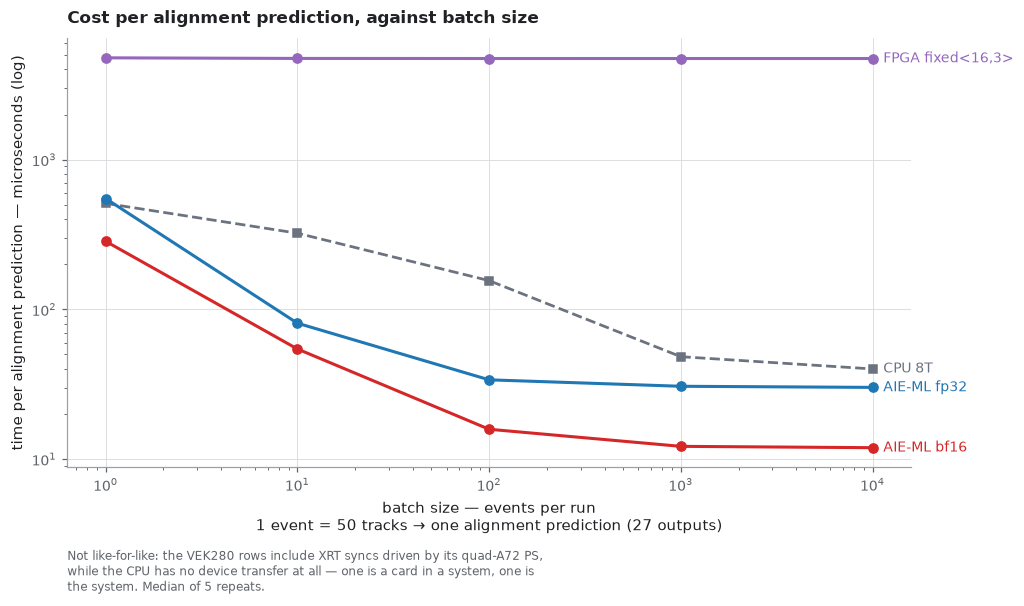

  µs per event, exactly as plotted

                               1        10       100     1,000    10,000
  AIE-ML fp32             550.07     80.89     33.86     30.67     30.14
  AIE-ML bf16             284.94     54.41     15.83     12.18     11.93
  FPGA fixed<16,3>       4783.11   4739.11   4733.71   4733.14   4733.02
  CPU fp32 8T             510.26    322.69    155.61     48.34     40.03


In [12]:
# A second copy of the comparison figure with ONE CPU line instead of three.
#
# Same data path as the figure above -- per_event_us() over primary() rows for
# the hardware, gpu_primary() for the GPU. Nothing is re-derived or typed in
# here, so the two figures cannot disagree.
CPU_ONE = 8                      # which thread count to keep

# The x axis is a BATCH SIZE, and "events" alone does not say that, nor what an
# event is. Both facts are in README.md's own chain:
#     50 tracks -> mean(128) -> dense 128->27 -> 27 outputs / event
# so one event is 50 tracks in and one 27-number prediction out. The repo calls
# the network "real-time track alignment" and the outputs "27 numbers per
# event"; it does not claim what those numbers physically are, so neither does
# this label.
XLABEL = ('batch size — events per run\n'
          '1 event = 50 tracks → one alignment prediction (27 outputs)')

# NOT "latency". The quantity is median(us_execute) / events: the run's device
# time divided by the predictions it produced. At 10,000 events the latency to
# the FIRST prediction is the whole 59 ms run -- this axis is throughput
# expressed per item, and calling it latency would be wrong at every batch size
# but 1.
YLABEL = 'time per alignment prediction — microseconds (log)'

if not RUNS or CPU.empty:
    print('(no data)')
else:
    HW = hw_per_event()
    fig, ax = plt.subplots(figsize=(9.2, 5.4))

    for impl, (ev, ue) in HW.items():
        ax.plot(ev, ue, marker='o', color=COL[impl], label=LABEL[impl], zorder=3)
        ax.annotate(LABEL[impl], (ev[-1], ue[-1]), textcoords='offset points',
                    xytext=(7, 0), color=COL[impl], fontsize=9, va='center')

    # The CPU in grey and dashed, not in the categorical palette. It is the
    # baseline the three VEK280 designs are being judged against rather than a
    # fourth design competing with them, and the style should say which is
    # which before the legend is read.
    CPU_GREY = '#6b7280'
    sub = CPU[CPU['threads'] == CPU_ONE]
    if not sub.empty:
        ev, ue = per_event_us(sub)
        ax.plot(ev, ue, marker='s', ms=5, ls='--', lw=1.8, color=CPU_GREY,
                label=f'CPU fp32, {CPU_ONE} threads (baseline)', zorder=2)
        ax.annotate(f'CPU {CPU_ONE}T', (ev[-1], ue[-1]), textcoords='offset points',
                    xytext=(7, 0), color=CPU_GREY, fontsize=9, va='center')

    # No GPU here on purpose. This figure is the three VEK280 implementations
    # against the host CPU they would replace; the GPU is a different question
    # and has the figure above and its own diagnostic below.

    ax.set_xscale('log'); ax.set_yscale('log')
    style(ax, 'Cost per alignment prediction, against batch size',
          XLABEL, YLABEL,
          'Not like-for-like: the VEK280 rows include XRT syncs driven by its '
          'quad-A72 PS,\nwhile the CPU has no device transfer at all — one is a '
          'card in a system, one is\nthe system. Median of 5 repeats.')
    save(fig, 'scan_vs_accel_8t.png'); plt.show()

    # Print every plotted point, so the figure can be checked against numbers
    # rather than read off by eye.
    print()
    series = {LABEL[i]: per_event_us(primary(r['df']))
              for i in IMPLS for r in RUNS if r['impl'] == i and r['target'] == 'hw'}
    if not sub.empty:
        series[f'CPU fp32 {CPU_ONE}T'] = per_event_us(sub)
    allev = sorted({int(e) for ev, _ in series.values() for e in ev})
    print('  µs per event, exactly as plotted\n')
    print('  ' + f'{"":<20}' + ''.join(f'{e:>10,}' for e in allev))
    for name, (ev, ue) in series.items():
        d = dict(zip((int(x) for x in ev), ue))
        print(f'  {name:<20}' + ''.join(
            (f'{d[e]:>10.2f}' if e in d else f'{"-":>10}') for e in allev))


In [ ]:
# A third copy of the comparison figure: the one above, plus the GPU.
#
# Cell 21 leaves the GPU out on purpose -- it asks "should this network run on
# the VEK280, or on the host CPU it would replace?", and a datacentre card is a
# different question. This asks that different question: the readout delivers
# ONE event at a time, so who wins at the batch size that actually arrives?
#
# Same data path as both figures above -- hw_per_event() over primary() rows,
# gpu_primary() for the GPU, XLABEL/YLABEL reused rather than retyped -- so none
# of the three figures can disagree with the others.

# Darker than cell 21's #6b7280. With the purple FPGA line in the same panel the
# lighter grey sits at dE 12.7 against it in NORMAL vision, below the 15 at which
# a full-colour reader can still separate two lines; #374151 moves the worst pair
# to purple-vs-red at dE 23.0. Still deliberately desaturated: the CPU is the
# baseline being judged against, not a fourth design competing for the win.
CPU_GREY_DARK = '#374151'

if not RUNS or CPU.empty or GPU.empty:
    print('(needs the hw, cpu and gpu scans together -- see gpu/README.md)')
else:
    gpu_name = GPU_META.get('gpu_model', 'GPU')
    HW = hw_per_event()
    fig, ax = plt.subplots(figsize=(8.4, 5.2))
    ends = []                     # (label, x, y, colour) for the direct labels

    for impl, (ev, ue) in HW.items():
        ax.plot(ev, ue, marker='o', ms=5, color=COL[impl], label=LABEL[impl],
                zorder=3)
        ends.append((LABEL[impl], ev[-1], ue[-1], COL[impl]))

    sub = CPU[CPU['threads'] == CPU_ONE]
    if not sub.empty:
        ev, ue = per_event_us(sub)
        ax.plot(ev, ue, marker='s', ms=5, ls='--', lw=1.8, color=CPU_GREY_DARK,
                label=f'CPU fp32, {CPU_ONE} threads (baseline)', zorder=2)
        ends.append((f'CPU fp32, {CPU_ONE} threads', ev[-1], ue[-1], CPU_GREY_DARK))

    GPU_CURVE = {}
    for v in GPU_PLOT:
        g = gpu_primary(v)
        if g.empty:
            continue
        ev, ue = per_event_us(g)
        GPU_CURVE[v] = (ev, ue)
        ax.plot(ev, ue, marker='^', ms=5, color=GPU_SHADE[v],
                label=f'GPU {v} ({gpu_name})', zorder=3)
        ends.append((f'GPU {v} ({gpu_name})', ev[-1], ue[-1], GPU_SHADE[v]))

    ax.set_xscale('log'); ax.set_yscale('log')

    # Headroom at the top for the two annotations, then labels placed against
    # the FINAL limits.
    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi * 9)
    lo, hi = ax.get_ylim()

    # Direct labels at the right edge, pushed apart where the lines converge.
    # Six series is past the point where colour alone identifies a line.
    span = np.log10(hi) - np.log10(lo)
    placed = []
    for lab, x, y, c in sorted(ends, key=lambda t: -t[2]):
        ly = np.log10(y)
        while placed and ly > placed[-1] - 0.052 * span:
            ly = placed[-1] - 0.052 * span
        placed.append(ly)
        ax.annotate(lab, (x, 10 ** ly), xytext=(9, 0), textcoords='offset points',
                    color=c, fontsize=8.6, va='center', annotation_clip=False)

    # The batch size the readout actually delivers. Everything to the right of
    # this band is a batching regime a streaming detector cannot reach without
    # buffering, which is the constraint Sec. 2 of the paper is about.
    ax.axvspan(0.86, 1.16, color=COL['aie_fp32'], alpha=0.08, zorder=0)
    ax.annotate('1 event — what the\nreadout delivers', (1, hi * 0.92),
                xytext=(7, 0), textcoords='offset points', fontsize=8.3,
                color=COL['aie_fp32'], va='top')

    # The crossover, interpolated from the measured points rather than eyeballed.
    # bf16 against bf16 so the comparison is like-for-like in precision.
    if 'bf16' in GPU_CURVE and 'aie_bf16' in HW:
        aev, aue = HW['aie_bf16']
        gev, gue = GPU_CURVE['bf16']
        xs = np.logspace(0, np.log10(max(aev.max(), gev.max())), 4000)
        d = (np.interp(np.log10(xs), np.log10(aev), np.log10(aue))
             - np.interp(np.log10(xs), np.log10(gev), np.log10(gue)))
        k = np.where(np.diff(np.sign(d)))[0]
        if len(k):
            xc = xs[k[0]]
            ax.axvline(xc, color='#6b7280', lw=1, ls=':', zorder=1)
            ax.annotate(f'crossover ~{xc:.0f} events ({xc * TRACKS_PER_EVENT:.0f} '
                        'tracks):\nbelow this the array is faster\nthan the GPU',
                        (xc, hi * 0.30), xytext=(8, 0), textcoords='offset points',
                        fontsize=8.3, color='#374151', va='top')

    style(ax, 'Cost per alignment prediction, against batch size',
          XLABEL, YLABEL,
          'Not like-for-like: the VEK280 rows include XRT syncs driven by its '
          'quad-A72 PS; the CPU has\nno device transfer at all; the GPU is a '
          f'{GPU_META.get("power_limit_w", "?")} W card on PCIe. '
          'Median of 5 repeats, mode=single.')
    ax.legend(loc='lower left', fontsize=8.3, framealpha=0.95, borderpad=0.5)
    save(fig, 'scan_cpu_gpu_vs_accel.png'); plt.show()

    # ---- and the crossing, stated rather than left to the eye --------------
    if 'bf16' in GPU_CURVE and 'aie_bf16' in HW:
        aev, aue = HW['aie_bf16']
        gev, gue = GPU_CURVE['bf16']
        common = sorted(set(aev.astype(int)) & set(gev.astype(int)))
        print()
        print(f'  {"events":>7} {"AIE-ML bf16":>13} {"GPU bf16":>11} {"ratio":>8}')
        for e in common:
            a = float(aue[list(aev.astype(int)).index(e)])
            g = float(gue[list(gev.astype(int)).index(e)])
            who = 'array' if a < g else 'GPU'
            print(f'  {e:>7} {a:>11.1f} us {g:>9.1f} us {max(a, g) / min(a, g):>7.1f}x  {who}')
        print()
        print('  The window in which the array wins is 1-2 events. That is the')
        print('  claim: at the batch a streaming readout delivers, the array beats')
        print('  a datacentre card and needs no host round trip -- NOT that it is')
        print('  faster in general, which it is not.')

  wrote analysis/out/scan_threads.png


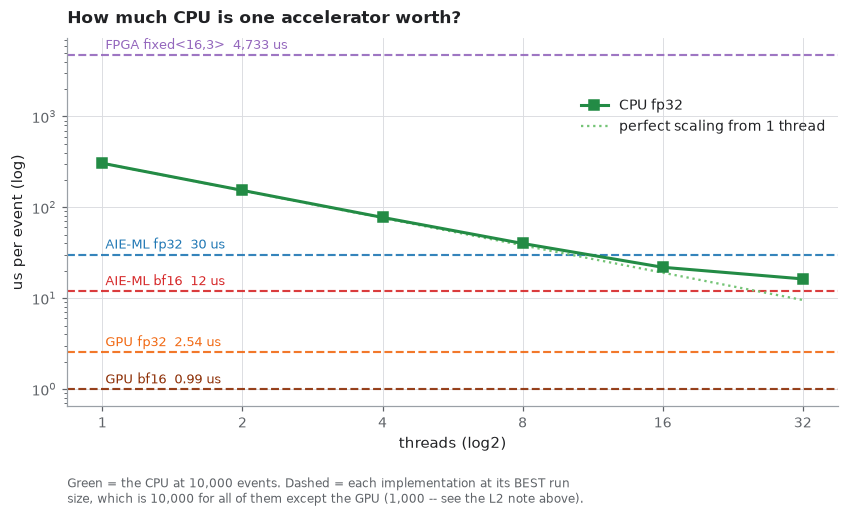


  implementation  best us/event  at events CPU threads to match vs CPU 1 thread vs CPU 8 threads
        GPU bf16           0.99       1000                  >32   308.7x faster     40.4x faster
        GPU fp32           2.54        500                  >32   120.2x faster     15.8x faster
     AIE-ML bf16          11.93      10000                  >32    25.6x faster      3.4x faster
     AIE-ML fp32          30.14      10000                   16    10.1x faster      1.3x faster
FPGA fixed<16,3>        4733.02      10000                    1    15.5x slower    118.2x slower

  CPU scaling at this run size:  1T 1.0x  2T 2.0x  4T 3.9x  8T 7.6x  16T 14.0x  32T 18.7x
  Best CPU: 16.3 us/event at 32 threads.


In [13]:
if CPU.empty or not RUNS:
    print('(no data)')
else:
    EV_MAX = int(CPU['events'].max())
    cpu_hi = (CPU[CPU['events'] == EV_MAX]
              .groupby('threads')['us_execute'].median() / EV_MAX)

    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    ax.plot(cpu_hi.index, cpu_hi.values, marker='s', color='#238b45',
            label='CPU fp32', zorder=3)

    # Ideal scaling from the 1-thread point: the gap to it IS the roll-off,
    # rather than something the reader has to infer from the curve's shape.
    t = np.array(cpu_hi.index, dtype=float)
    ax.plot(t, cpu_hi.iloc[0] / t, ls=':', color='#74c476', lw=1.5,
            label='perfect scaling from 1 thread', zorder=2)

    HW = hw_per_event()

    def best(ev, ue):
        """Lowest per-event cost across the sweep, and where it happened.

        NOT the value at the largest run. Every implementation here except the
        GPU improves monotonically, so for them the two are identical -- but the
        GPU is fastest at 1000 events and 2-3x worse at 10000, because one
        (n,128) activation stops fitting in the L40S's 96 MB L2. Scoring it at
        the largest run would report a cache cliff as if it were the card.
        """
        k = int(np.argmin(ue))
        return float(ue[k]), int(ev[k])

    # The GPU joins the accelerators as a horizontal: it has no thread axis, so
    # what it contributes here is "the level a whole card reaches".
    GPU_LEVEL = {}
    for v in GPU_PLOT:
        g = gpu_primary(v)
        if not g.empty:
            GPU_LEVEL[v] = best(*per_event_us(g))

    for impl, (ev, ue) in HW.items():
        y = best(ev, ue)[0]
        ax.axhline(y, color=COL[impl], ls='--', lw=1.4, alpha=0.9, zorder=1)
        # Labelled at the LEFT edge: the CPU and ideal lines converge on the
        # right, and labels there collided with both them and the legend.
        ax.annotate(f'{LABEL[impl]}  {y:,.0f} us',
                    (t[0], y), textcoords='offset points', xytext=(2, 4),
                    color=COL[impl], fontsize=8.5, ha='left')

    for v, (y, at) in GPU_LEVEL.items():
        ax.axhline(y, color=GPU_SHADE[v], ls='--', lw=1.4, alpha=0.9, zorder=1)
        ax.annotate(f'GPU {v}  {y:,.2f} us', (t[0], y), textcoords='offset points',
                    xytext=(2, 4), color=GPU_SHADE[v], fontsize=8.5, ha='left')

    ax.set_xscale('log', base=2); ax.set_yscale('log')
    ax.set_xticks(t); ax.set_xticklabels([int(v) for v in t])
    style(ax, 'How much CPU is one accelerator worth?',
          'threads (log2)', 'us per event (log)',
          'Green = the CPU at 10,000 events. Dashed = each implementation at its '
          'BEST run\nsize, which is 10,000 for all of them except the GPU '
          '(1,000 -- see the L2 note above).')
    # Below the FPGA line, in the one large empty region of the panel.
    ax.legend(loc='upper right', bbox_to_anchor=(1.0, 0.87))
    save(fig, 'scan_threads.png'); plt.show()

    # ---- the crossings, stated rather than eyeballed ----------------------
    print()

    def ratio(cpu_us, accel_us):
        """Signed, in words. A bare '0.0x' hides that the PL design is two
        orders of magnitude off, and reads as if it were merely rounding."""
        r = cpu_us / accel_us
        return f'{r:,.1f}x faster' if r >= 1 else f'{1 / r:,.1f}x slower'

    rows = []
    levels = [(LABEL[impl], *best(ev, ue)) for impl, (ev, ue) in HW.items()]
    levels += [(f'GPU {v}', y, at) for v, (y, at) in GPU_LEVEL.items()]
    for name, y, at in levels:
        beat = [n for n in cpu_hi.index if cpu_hi[n] <= y]
        rows.append({
            'implementation': name,
            'best us/event': round(y, 2),
            'at events': at,
            'CPU threads to match': (min(beat) if beat
                                     else f'>{int(cpu_hi.index.max())}'),
            'vs CPU 1 thread': ratio(cpu_hi.iloc[0], y),
            'vs CPU 8 threads': (ratio(cpu_hi[8], y) if 8 in cpu_hi.index else '-'),
        })
    CPU_CROSS = (pd.DataFrame(rows).sort_values('best us/event')
                 .reset_index(drop=True))
    print(CPU_CROSS.to_string(index=False))
    print()
    sp = cpu_hi.iloc[0] / cpu_hi
    print('  CPU scaling at this run size:  ' +
          '  '.join(f'{n}T {sp[n]:.1f}x' for n in cpu_hi.index))
    print(f'  Best CPU: {cpu_hi.min():.1f} us/event at '
          f'{int(cpu_hi.idxmin())} threads.')


  wrote analysis/out/scan_gpu_dispatch.png


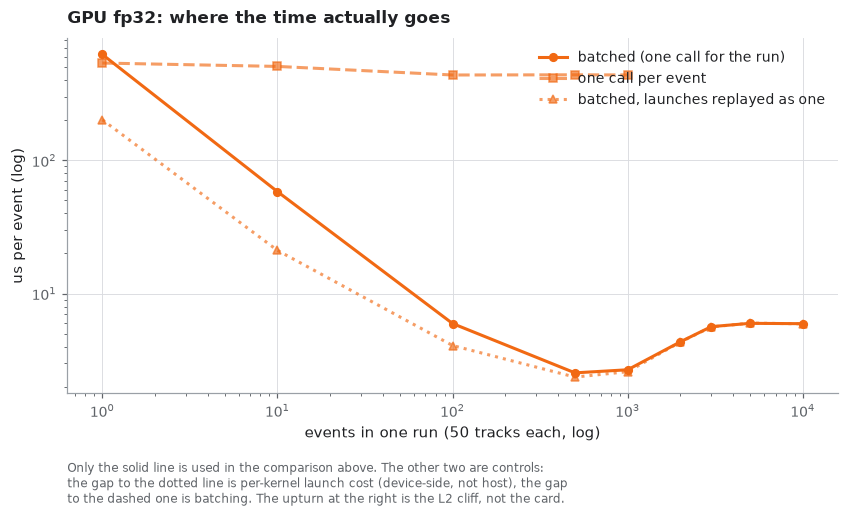


  us per event, GPU fp32, median of 5 reps
mode     fresh   graph  single
events                        
1       538.00  201.66  624.04
10      507.54   21.10   58.27
100     437.57    4.08    5.96
500     439.01    2.36    2.54
1000    437.96    2.59    2.68
2000       NaN    4.33    4.35
3000       NaN    5.62    5.65
5000       NaN    6.01    5.98
10000      NaN    5.93    5.95

  launch cost, single minus graph: 422.4 us/event at 1 event(s) -> 0.02 at 10000.
  A fixed cost per call, so it divides away with batch size.
  batching is worth 163.4x at 1,000 events (fresh / single).

  wall-clock kernel time vs pure GPU time (cuda events), per CALL:
        us_kernel  cuda_us  host us  gpu busy %
events                                         
1           562.8    538.5     24.3        95.7
10          519.2    494.3     24.9        95.2
100         525.7    499.5     26.2        95.0
500        1152.3   1130.7     21.6        98.1
1000       2517.3   2496.7     20.6        99.2
2000  

In [14]:
if GPU.empty:
    print('(no GPU scan)')
else:
    # The launch story, stated as numbers -- and it did not come out the way
    # it was predicted, which is why the control exists.
    #
    # One forward pass is ~50 kernels: 3 per dense x 14, plus the roll-concat's
    # slice and join x 3. That count does NOT grow with batch size, so it is a
    # fixed floor per call. The GUESS was that the floor is the host issuing
    # them. The cuda-event column below says otherwise -- the GPU is ~95% busy
    # even at one event, so the floor is DEVICE-side per-kernel launch latency
    # across 50 tiny kernels. mode=graph replays them as one and removes it.
    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    MODE_STYLE = {'single': ('-', 'o', 'batched (one call for the run)'),
                  'fresh':  ('--', 's', 'one call per event'),
                  'graph':  (':', '^', 'batched, launches replayed as one')}
    v0 = GPU_PLOT[0] if not GPU[GPU['variant'] == GPU_PLOT[0]].empty else GPU['variant'].iloc[0]
    for mode, (ls, mk, lab) in MODE_STYLE.items():
        sub = GPU[(GPU['variant'] == v0) & (GPU['mode'] == mode)]
        if sub.empty:
            continue
        ev, ue = per_event_us(sub)
        ax.plot(ev, ue, ls=ls, marker=mk, ms=5, color=GPU_SHADE[v0],
                alpha=1.0 if mode == 'single' else 0.65, label=lab, zorder=3)

    ax.set_xscale('log'); ax.set_yscale('log')
    style(ax, f'GPU {v0}: where the time actually goes',
          'events in one run (50 tracks each, log)', 'us per event (log)',
          'Only the solid line is used in the comparison above. The other two '
          'are controls:\nthe gap to the dotted line is per-kernel launch cost '
          '(device-side, not host), the gap\nto the dashed one is batching. The '
          'upturn at the right is the L2 cliff, not the card.')
    ax.legend(loc='upper right')
    save(fig, 'scan_gpu_dispatch.png'); plt.show()

    # ---- and the same thing as a table -----------------------------------
    print()
    piv = (GPU[GPU['variant'] == v0]
           .groupby(['mode', 'events'])['us_execute'].median().unstack('mode'))
    piv = (piv.div(piv.index.to_series(), axis=0)).round(2)
    piv.index.name = 'events'
    print(f'  us per event, GPU {v0}, median of {int(GPU_META.get("reps", 0) or 0)} reps')
    print(piv.to_string())
    if {'single', 'graph'} <= set(piv.columns):
        d = (piv['single'] - piv['graph']).dropna()
        if len(d):
            print(f'\n  launch cost, single minus graph: '
                  f'{d.iloc[0]:,.1f} us/event at {int(d.index[0])} event(s) -> '
                  f'{d.iloc[-1]:,.2f} at {int(d.index[-1])}.')
            print('  A fixed cost per call, so it divides away with batch size.')

    if {'single', 'fresh'} <= set(piv.columns):
        r = (piv['fresh'] / piv['single']).dropna()
        if len(r):
            print(f'  batching is worth {r.iloc[-1]:,.1f}x at '
                  f'{int(r.index[-1]):,} events (fresh / single).')

    # ---- host or device? The cuda events answer it, and they overruled the
    # ---- prediction that this floor was Python.
    g = GPU[GPU['variant'] == v0].copy()
    g['cuda_us'] = g['notes'].fillna('').str.extract(r'cuda_event_us=([\d.]+)')[0].astype(float)
    g = g[(g['mode'] == 'single') & g['cuda_us'].notna()]
    if not g.empty:
        h = g.groupby('events')[['us_kernel', 'cuda_us']].median()
        h['host us'] = (h['us_kernel'] - h['cuda_us']).round(1)
        h['gpu busy %'] = (100 * h['cuda_us'] / h['us_kernel']).round(1)
        print('\n  wall-clock kernel time vs pure GPU time (cuda events), per CALL:')
        print(h.round(1).to_string())
        print(f"\n  The host contributes ~{h['host us'].median():.0f} us per call at every "
              'size. It is not the bottleneck at any\n  point -- the small-batch floor '
              'is the card launching 50 tiny kernels, not Python issuing them.')

    # ---- the cache cliff, and the cross-precision test that identifies it --
    #
    # This GPU is the only non-monotone curve in the notebook, and the cause is
    # testable rather than assertable. If the upturn is a CACHE effect it must
    # happen at a fixed number of BYTES, so:
    #
    #   fp32 and tf32 both use float32 storage -> same tensor -> same turn point
    #   bf16 halves the tensor                  -> turn point doubles IN EVENTS
    #
    # If instead all three turned at the same event count, it would be something
    # about the run size and this explanation would be wrong.
    ITEMSIZE = {'fp32': 4, 'tf32': 4, 'bf16': 2}
    turn = {}
    for v in sorted(GPU['variant'].unique()):
        g2 = gpu_primary(v)
        if g2.empty:
            continue
        ev, ue = per_event_us(g2)
        k = int(np.argmin(ue))
        turn[v] = (int(ev[k]), float(ue[k]),
                   ev[k] * TRACKS_PER_EVENT * 128 * ITEMSIZE.get(v, 4) / 1e6)
    if turn and max(e for e, _, _ in turn.values()) != int(GPU['events'].max()):
        print('\n  Where each precision stops improving:\n')
        print(f"    {'variant':>8} {'best at':>10} {'us/event':>10} {'one (n,128) activation':>24}")
        for v, (ev, us, mb) in turn.items():
            print(f'    {v:>8} {ev:>7,} ev {us:>10.2f} {mb:>21.1f} MB')
        sizes = {round(mb, 1) for _, _, mb in turn.values()}
        print(f"\n    All of them peak at the same {list(sizes)[0]:.1f} MB activation"
              if len(sizes) == 1 else
              f"\n    Peak activation sizes differ: {sorted(sizes)} MB")
        if 'fp32' in turn and 'bf16' in turn:
            r = turn['bf16'][0] / turn['fp32'][0]
            print(f"    bf16's turn point is {r:.1f}x fp32's in EVENTS, and bf16 tensors "
                  f"are half the size.\n    That is a cache effect and not a run-size "
                  f"effect: the L40S has 96 MB of L2,\n    and every one of the 14 layers "
                  f"reads and writes one of these tensors, so\n    several are live at "
                  f"once. Past that point they all stream from GDDR6.")
    # ---- what the precisions cost, which is the OTHER reason tf32 is here --
    print()
    accs = []
    for v in sorted(GPU['variant'].unique()):
        g = gpu_primary(v)
        if g.empty:
            continue
        ev, ue = per_event_us(g)
        k = int(np.argmin(ue))
        accs.append({'variant': v,
                     'best us/event': round(float(ue[k]), 2),
                     'at events': int(ev[k]),
                     'us/event @10000': round(float(ue[-1]), 2),
                     'checksum @10000': g[g['events'] == g['events'].max()]['mean_checksum'].iloc[0]})
    if accs:
        print('  ' + pd.DataFrame(accs).to_string(index=False).replace(chr(10), chr(10) + '  '))
        print('\n  tf32 is float32 storage with ~10-bit-mantissa matmuls. It is')
        print('  measured to show what "fp32" silently becomes on this hardware')
        print('  if the backend flags are left at their defaults.')


## 9. Summary

In [15]:
if not RUNS:
    print('(no data)')
else:
    summary = []
    for r in impl_runs('hw') or impl_runs('hw_emu'):
        impl, m = r['impl'], r['meta']
        p = primary(r['df'])
        if p.empty:
            continue
        g = agg(p, 'us_execute')
        ev_lo, ev_hi = g.index.min(), g.index.max()
        lo, hi = g.loc[ev_lo], g.loc[ev_hi]
        ns_hi = hi['median'] * 1e3 / (ev_hi * TRACKS_PER_EVENT)
        gops_hi = (OPS_PER_MAC * MACS_PER_TRACK * ev_hi * TRACKS_PER_EVENT
                   / (hi['median'] * 1e-6) / 1e9)
        summary.append({
            'implementation': LABEL[impl],
            'source': r['target'],
            'reps': int(hi['count']),
            f'ns/track @{int(ev_lo)}ev': round(lo['median'] * 1e3 / (ev_lo * TRACKS_PER_EVENT), 1),
            f'ns/track @{int(ev_hi)}ev': round(ns_hi, 1),
            'spread @max %': round(100 * (hi['max'] - hi['min']) / hi['median'], 1),
            'GOP/s @max': round(gops_hi, 1),
            'once: xclbin open ms': round(float(m.get('us_xclbin_open') or 0) / 1e3, 1),
            'once: RTP load ms': round(float(m.get('us_rtp_load') or 0) / 1e3, 1),
        })
    # The CPU baseline, on the same basis. It is appended here rather than
    # joining impl_runs() so that sections 1-7 stay about the three hardware
    # implementations and their figures do not change.
    if not CPU.empty:
        for n in sorted(CPU['threads'].unique()):
            g = agg(CPU[CPU['threads'] == n], 'us_execute')
            ev_lo, ev_hi = g.index.min(), g.index.max()
            lo, hi = g.loc[ev_lo], g.loc[ev_hi]
            summary.append({
                'implementation': f'CPU fp32 {int(n)}T',
                'source': 'native',
                'reps': int(hi['count']),
                f'ns/track @{int(ev_lo)}ev': round(lo['median'] * 1e3 / (ev_lo * TRACKS_PER_EVENT), 1),
                f'ns/track @{int(ev_hi)}ev': round(hi['median'] * 1e3 / (ev_hi * TRACKS_PER_EVENT), 1),
                'spread @max %': round(100 * (hi['max'] - hi['min']) / hi['median'], 1),
                'GOP/s @max': round(OPS_PER_MAC * MACS_PER_TRACK * ev_hi * TRACKS_PER_EVENT
                                    / (hi['median'] * 1e-6) / 1e9, 1),
                'once: xclbin open ms': 0.0,     # no device to open
                'once: RTP load ms': 0.0,
            })

    # The GPU, on the same basis. mode=single only -- fresh and graph are
    # diagnostics and belong in the section above, not in a headline table.
    if not GPU.empty:
        for v in sorted(GPU['variant'].unique()):
            g = agg(gpu_primary(v), 'us_execute')
            if g.empty:
                continue
            ev_lo, ev_hi = g.index.min(), g.index.max()
            lo, hi = g.loc[ev_lo], g.loc[ev_hi]
            summary.append({
                'implementation': f'GPU {v}',
                'source': 'native',
                'reps': int(hi['count']),
                f'ns/track @{int(ev_lo)}ev': round(lo['median'] * 1e3 / (ev_lo * TRACKS_PER_EVENT), 1),
                f'ns/track @{int(ev_hi)}ev': round(hi['median'] * 1e3 / (ev_hi * TRACKS_PER_EVENT), 1),
                'spread @max %': round(100 * (hi['max'] - hi['min']) / hi['median'], 1),
                'GOP/s @max': round(OPS_PER_MAC * MACS_PER_TRACK * ev_hi * TRACKS_PER_EVENT
                                    / (hi['median'] * 1e-6) / 1e9, 1),
                'once: xclbin open ms': 0.0,
                'once: RTP load ms': 0.0,
            })

    S = pd.DataFrame(summary)
    print(S.to_string(index=False))

    S.to_csv(OUTD / 'scan_summary.csv', index=False)
    print()
    print('  wrote', (OUTD / 'scan_summary.csv').relative_to(REPO))

    # ---- the report --------------------------------------------------------
    # Written to a file, not just printed, so the result exists outside a
    # notebook that has to be re-run to be read.
    L = []
    L.append('# RTDA performance scan\n')
    srcs = sorted({r['target'] for r in RUNS})
    L.append(f"Generated by `analysis/rtda_scan.ipynb`. Source: {', '.join(srcs)}.\n")
    for r in RUNS:
        m = r['meta']
        L.append(f"- **{LABEL[r['impl']]}** ({r['target']}): `{m.get('xclbin','?')}`, "
                 f"{m.get('reps','?')} repeats, stimulus {m.get('stimulus_events','?')} "
                 f"events, rev `{m.get('git_hash','?')}`, {m.get('date_utc','?')}")
    if not CPU.empty:
        L.append(f"- **CPU fp32** (native): {CPU_META.get('cpu_model','?')}, "
                 f"{CPU_META.get('cores','?')} logical cores, "
                 f"{CPU_META.get('reps','?')} repeats, threads "
                 f"{CPU_META.get('threads_list','?')}, "
                 f"chunk {CPU_META.get('chunk_events','?')} events, "
                 f"rev `{CPU_META.get('git_hash','?')}`, {CPU_META.get('date_utc','?')}")
    if not GPU.empty:
        L.append(f"- **GPU** (native): {GPU_META.get('gpu_model','?')}, "
                 f"driver {GPU_META.get('driver','?')}, cuda {GPU_META.get('cuda','?')}, "
                 f"torch {GPU_META.get('torch','?')}, "
                 f"{GPU_META.get('reps','?')} repeats, "
                 f"variants {GPU_META.get('variants_list','?')}, "
                 f"modes {GPU_META.get('modes','?')}, "
                 f"rev `{GPU_META.get('git_hash','?')}`, {GPU_META.get('date_utc','?')}")
    L.append('\n## Headline\n')
    L.append(md_table(S))
    L.append('\n## Scaling fits\n')
    L.append('`us_execute = fixed + marginal x tracks`. The fixed term is paid once '
             'per invocation and is host/driver side; the marginal term is what the '
             'design costs per track.\n')
    for r in impl_runs('hw') or impl_runs('hw_emu'):
        p = primary(r['df'])
        if p.empty or p['events'].nunique() < 2:
            continue
        g = agg(p, 'us_execute')
        tr = g.index.to_numpy(float) * TRACKS_PER_EVENT
        A = np.column_stack([np.ones_like(tr), tr])
        (fx, mg), *_ = np.linalg.lstsq(A, g['median'].to_numpy(float), rcond=None)
        L.append(f"- **{LABEL[r['impl']]}**: {fx:,.1f} us fixed + {mg*1e3:,.1f} ns/track")
    pl = [r for r in RUNS if r['impl'] == 'pl_fixed']
    if pl:
        t = pl[0]['df']
        t = t[t['mode'] == 'tpc'].sort_values('tracks_per_call')
        if len(t) >= 2:
            n = t['tracks_per_call'].to_numpy(float)
            y = t['us_call_med'].to_numpy(float)
            A = np.column_stack([np.ones_like(n), n])
            (fx, mg), *_ = np.linalg.lstsq(A, y, rcond=None)
            L.append('\n## The PL bottleneck\n')
            L.append(f'- fit over tracks-per-call: **{fx:,.1f} us fixed per call + '
                     f'{mg:.2f} us/track**')
            L.append(f'- csynth predicts {PL_CSYNTH_US_PER_TRACK:.2f} us/track '
                     f'({PL_CSYNTH_CYCLES} cycles @ {PL_CLOCK_MHZ:.0f} MHz)')
    if not CPU.empty and 'CPU_CROSS' in dir():
        L.append('\n## Against the host CPU\n')
        L.append('Not like-for-like: the accelerator rows include XRT syncs driven '
                 'by the VEK280 quad-A72 PS, while the CPU has no device transfer '
                 'at all and runs on a '
                 f"{CPU_META.get('cpu_model','?')}. "
                 'That asymmetry is the comparison, not a defect in it.\n')
        L.append(md_table(CPU_CROSS))
    if not GPU.empty:
        L.append('\nThe GPU rows are `mode=single` -- one transfer, one forward, '
                 'one transfer back for the whole run -- which is the shape every '
                 'other implementation is measured in. Its `fresh` and `graph` '
                 'rows are diagnostics and are not in this table.')
    if FIGS:
        L.append('\n## Figures\n')
        L.append('One plot per file, in `analysis/out/`:\n')
        for _f in FIGS:
            L.append(f'- `{_f}`')
    L.append('\n## Caveats\n')
    L.append('- The AIE has **no H2D/D2H split**: input DMA, compute and output DMA '
             'overlap by design, so `us_h2d` is an issue cost and `us_d2h` an '
             'un-overlapped tail. Only the PL numbers are real per-phase transfers.')
    L.append('- `mean_checksum` is a smoke value, not accuracy. Accuracy lives in '
             '`analysis/rtda_compare.ipynb`.')
    L.append('- Not measured: power, DDR bandwidth ceiling, multi-CU scaling.')
    L.append('- The GPU baseline runs **gpu/rtda_torch.py**, a torch transcription '
             'of `model/rtda_ref.py` gated against it at float64 on every run. It '
             'is the only second copy of the forward pass in this repo, and the '
             'gate is why it cannot drift. Its `us_h2d`/`us_d2h` are real PCIe '
             'transfers -- unlike every other non-PL row here.')
    L.append('- **`variant=tf32` is not a separate design.** It is float32 storage '
             'with ~10-bit-mantissa matmuls, which is what "fp32" silently becomes '
             'on this hardware if the torch backend flags are left alone. It is '
             'measured to make that visible, not because anyone chose it.')
    L.append('- The CPU baseline is **fp32 on a 32-core host**, chunked 50 events at '
             'a time with BLAS pinned to one thread per worker. Below ~100 events '
             'there are fewer chunks than threads, so its thread count stops '
             'mattering -- that is the chunk size, not the CPU.')
    L.append('- `mode=tpc` rows are timing only -- the 128-wide mean is not an event '
             'mean at those track counts.')
    (OUTD / 'scan_report.md').write_text('\n'.join(L) + '\n')
    print('  wrote', (OUTD / 'scan_report.md').relative_to(REPO))

  implementation source  reps  ns/track @1ev  ns/track @10000ev  spread @max %  GOP/s @max  once: xclbin open ms  once: RTP load ms
     AIE-ML fp32     hw     5        11001.4              602.9            0.0       876.5                 233.7                5.6
     AIE-ML bf16     hw     5         5698.8              238.6            0.1      2214.7                 229.4                4.7
FPGA fixed<16,3>     hw     5        95662.3            94660.5            0.0         5.6                 179.5                0.0
     CPU fp32 1T native     5         9300.4             6111.0            0.5        86.5                   0.0                0.0
     CPU fp32 2T native     5        10293.3             3072.6            0.1       172.0                   0.0                0.0
     CPU fp32 4T native     5         9218.9             1549.5            0.2       341.0                   0.0                0.0
     CPU fp32 8T native     5        10205.1              800.6            1

## What this notebook does not measure

- **Power.** `pl_fixed/plot_power.py` and the `*.csv` beside it are a separate,
  older measurement.
- **The DDR bandwidth ceiling.** Buffers here are tens of MB and the transfers are
  not the limit at any point in this sweep, but nothing above proves that.
- **Multi-CU or multi-graph scaling.** One CU, one graph, one at a time.
- **The AIE H2D/D2H split**, which is structurally unavailable — see §3.
- **Accuracy.** Deliberately: `mean_checksum` catches a dead device and nothing
  more. `analysis/rtda_compare.ipynb` owns correctness, against the ONNX
  reference, with the warm-up convention handled properly.
- **A like-for-like comparison with the CPU or the GPU.** §8 puts both on the same axes,
  but one side is a card in a system and the other is the system. The CPU
  pays no PCIe/AXI transfer and no XRT launch; the accelerators do, driven
  by a quad-A72 PS. Read it as "what does this network cost on each", not
  as a controlled experiment.
- **The GPU at its best.** The plotted GPU line is plain PyTorch. §8's
  `graph` rows show what removing host dispatch is worth, but no attempt was
  made to fuse the network, tune kernels, or use TensorRT — so the GPU line
  is a floor on that hardware, not a ceiling.
